# Synthetic rainfall: evaluation of every version and ablation

**Scope.** Every generated 5-minute rainfall series in this project, from the first prototype
(v1) to the current baseline (v14) and the newest experiments (E1 attention, E2 context
chaining), plus classical baselines, including the field's standard storm-and-cell model
(randomised Bartlett-Lewis). Each is scored on **hydrology** (does it
rain like Astlingen?) and on **generative-model** quality (does the model cover the data, can a
classifier tell it apart, is it memorising, is it useful for learning?).

**Headline results** (details and evidence in each section; claims table in §6):

1. **v14 (asinh transform) is the best model.** Gate A 14/18 (v10: 11/18). Against v10 on the
   same 10 planned years it adds **+9.4% rain volume (10/10 years)**, **+2.8 min wet spells
   (10/10)**, **+3.2 min storm duration (9/10)**, and its stormiest state is **8%** short of real
   rain instead of **34%**. Mechanism: it brings back the drizzle at storm edges.
2. **Removing bridge blocks fixes the seasons**: monthly-cycle correlation **0.62 → 0.97**,
   the first diffusion version to pass the seasonality check.
3. **Diffusion and the classical storm-and-cell model fail in opposite places.** Diffusion gets
   the 5-minute texture right (short showers, sharp bursts, window realism) but misses long storms;
   the storm-and-cell model gets long storms (13.8/yr vs real 14.25), daily totals and hourly
   persistence right but its 5-minute texture is wrong (7% single-step showers vs 38%; bursts 40%
   too weak). The first AR / latent Gaussian baselines lost to diffusion almost everywhere, but that was
   their fit: a latent Gaussian AR whose latent correlation is matched to rain occurrence (refit
   Oct 5) gets wet/dry texture and long storms right (15.8/yr) and is the hardest series for a
   classifier to detect (AUC 0.56 vs v14 0.78). One latent process then makes heavy rain persist:
   extremes 1.3–1.9× real from 1 hour up and sewer overflow 1.47× real (v14 0.62×, v16 1.00×).
4. **Not fixed: the block-boundary cliff.** Every independently-generated version makes
   ≤ 2 storms/yr longer than 5h20 (real 14.25). Attention (E1) made storms *shorter*
   (−3.5 min, 0/10 years). **Context chaining (E2) removes the cliff** (survival at 320 min
   0.13 → 0.73–0.79, inside the real range) **but halves the rain**; a pilot traces that to
   RePaint resampling, which gives the **one good idea** in §7.
5. **The evaluation itself needed calibrating**: two real held-out years, scored as if they were
   a generator, pass only **10/18** Gate A checks.
6. **Against the official German design-rainfall table (KOSTRA) for the Erft basin**, the real
   gauges agree within about 5% from 15 minutes to a day. The project's series is the *average of
   four gauges*, whose 5-minute peaks are about 40% below a single gauge's, so the right yardstick
   for the models is the real average: v14 is within about 10% of it up to 1 hour, 25% short at
   1 day (§3.7).

**Contents.**
0 How this evaluation works ·
1 What was generated ·
2 The big picture (Gate A across history) ·
3 Hydrology (3.1 water & occurrence · 3.2 intensity · 3.3 storms and the cliff · 3.4 extremes ·
3.5 structure across time scales · 3.6 seasons and years · 3.7 official heavy-rain table) ·
4 Generative-model metrics (4.1 noise floor · 4.2 coverage & realism of windows ·
4.3 memorisation · 4.4 utility · 4.5 conditioning · 4.6 inside the diffusion model) ·
5 Ablations, year by year ·
6 What can be reported ·
7 One good idea ·
Appendix

## 0. How this evaluation works

**Reference.** The 2000–2007 training years, the canonical baseline used by
`scripts/gate_a_scorecard.py` (whose definitions are reused, so Gate A numbers match).

**Noise floor.** A synthetic series will never match the reference exactly, and neither will
new *real* data. So the question is not "is the distance zero?" but "is it as small as the
distance between real samples?". The floor comes from real 2-year samples that are not in the
reference: the held-out years **2008–2009** (no model trained on them except v7) and
leave-two-years-out chunks of 2000–2007. Generated series are cut into 2-year chunks and scored
the same way.

**Uncertainty.** Each version is one trained model and one generated realisation, so there is
no training-seed spread. What *can* be tested: v10, v13, v14, v15, v15_ctrl and the
24-step-checkpoint control were generated from the **same seed-42 state plan**, so their year
*y* faces the same weather regimes. Differences between them are tested **year by year** (10
paired years; mean, 95% interval, and how many years agree).

| Family | Metrics | Why it matters here |
| :--- | :--- | :--- |
| Water & occurrence | volume, dry fraction, P(wet \| wet), wet / dry spells, single-step showers | water balance and how rain switches on and off drive sewer filling |
| Intensity | wet-step quantiles, exceedance curve, Wasserstein distance | overflow happens in the tail |
| Storms | count, duration, depth, survival curve, storms > 320 min | long storms carry 21% of real rain and cause floods |
| Extremes | annual maxima, Gumbel IDF ratios at 15 min–24 h | design-storm relevance |
| Time structure | lag-1 ACF, hourly ACF, variance across aggregation scales | persistence that a controller must anticipate |
| Seasons & years | monthly and diurnal cycle, interannual variability | realistic RL episodes across the year |
| Distribution distance | Wasserstein / KS / JSD against the real noise floor | is the gap bigger than real-vs-real? |
| Coverage | precision, recall, density, coverage of 5-h windows (Naeem et al. 2020) | fidelity vs diversity of a generative model |
| Realism | classifier two-sample test (C2ST) on 5-h and 1-day windows | can a model tell synthetic from real? |
| Memorisation | nearest-training-window distance vs held-out real | is the model copying its training data? |
| Utility | train a forecaster on synthetic, test on real (TSTR) | does synthetic data teach real relationships? |
| Conditioning | rain per HMM state, generated vs real | does the label steer the output? |
| Model internals | denoising error by rain band, training loss, sampling cost | why the numbers above come out as they do |

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join('..', 'scripts')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import eval_suite as ev

E = ev.compute()        # loads results/evaluation/eval_cache.pkl; recomputes (~4 min) if a data file changed
META = ev.META
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220); pd.set_option('display.precision', 3)

# One colour per entity for the whole notebook (dataviz palette, categorical slots 1-4);
# everything else is context grey, the real record is dark grey.
C = {'v10': '#2a78d6', 'v14': '#eb6834', 'v14_ctx': '#1baf7a', 'bartlett_lewis': '#eda100'}
REAL, CTX = '#52514e', '#c3c2b7'
INK, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
                     'axes.edgecolor': AXIS, 'axes.labelcolor': INK, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.axisbelow': True, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
                     'legend.frameon': False, 'lines.linewidth': 2})

def lab(n):
    return META.loc[n, 'label'] if n in META.index else n

def col(n):
    return C.get(n, REAL if str(n).startswith('real') else CTX)

H = pd.DataFrame(E['hydro']).T                                   # one row per series
W = pd.DataFrame(E['windows']).T
T = pd.DataFrame(E['tstr']).T
GATE = {n: g for n, g in E['gate'].items() if g}
TALLY = pd.Series({n: sum(g.values()) for n, g in GATE.items()})
CLEAN = [n for n in META.index if META.loc[n, 'clean'] and n in H.index and not n.startswith('arima')]
BASE = ['bartlett_lewis', 'arima_len64', 'arima_copula_len64', 'arima_copula_occ_len64', 'arima_copula_seas_markov_len64']
KEY = ['v10', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal', 'v14_ctx', 'bartlett_lewis']
print(f"{len(H) - 2} generated series scored against the 2000-2007 reference; cache: {os.path.relpath(ev.CACHE)}")

36 generated series scored against the 2000-2007 reference; cache: ../results/evaluation/eval_cache.pkl


## 1. What was generated

Every series, the experiment it belongs to and what changed. "Clean" = trained only on
2000–2007. v1–v7 predate the clean split (v7 even trained on the held-out years). v3 and v4 are
10-minute series and are scored at hourly and coarser scales only. The two E2 runs are
**partial**: 4 independent chains × 2 years each (the jobs were stopped), placed one after another.

In [2]:
reg = META[['group', 'change', 'L', 'clean']].copy()
reg['years'] = pd.Series(E['years']).round(1)
reg['Gate A'] = TALLY.reindex(reg.index).map(lambda v: '' if pd.isna(v) else f'{int(v)}/18')
reg.index = [lab(n) for n in reg.index]
reg.rename(columns={'L': 'block (steps)'})

,group,change,block (steps),clean,years,Gate A
v1,early,first 5-min model (unconditional),NaN,False,10.0,2/18
v2,early,v1 + negative-value thresholding,NaN,False,10.0,2/18
v3,early,"unconditional, 10-min resolution",NaN,False,10.0,
v4,early,"4 GMM regime classes, 10-min resolution",NaN,False,10.0,
v5,early,4 seasonal-phase classes (daily features),NaN,False,10.0,4/18
v6,early,4 seasonal-phase classes (day of year),NaN,False,10.0,3/18
v7,early,"4 seasonal-phase classes, trained on 2000-2009...",NaN,False,10.0,7/18
v8 L24,context length,"clean 2000-2007 split, 2-h blocks",24.0,True,10.0,5/18
v9 L36,context length,3-h blocks,36.0,True,10.0,4/18
v10 L64,context length,5h20 blocks (previous best),64.0,True,10.0,11/18


## 2. The big picture: Gate A across history

Gate A is the project's acceptance scorecard: 18 pass/fail checks across water balance,
intensity, storms, extremes and seasons (`code_plan/ACCEPTANCE_CRITERIA.md`). Below, every
5-minute series against the same 18 checks, **and the two real held-out years scored as if they
were a generator** — the calibration point a perfect model could not beat by much.

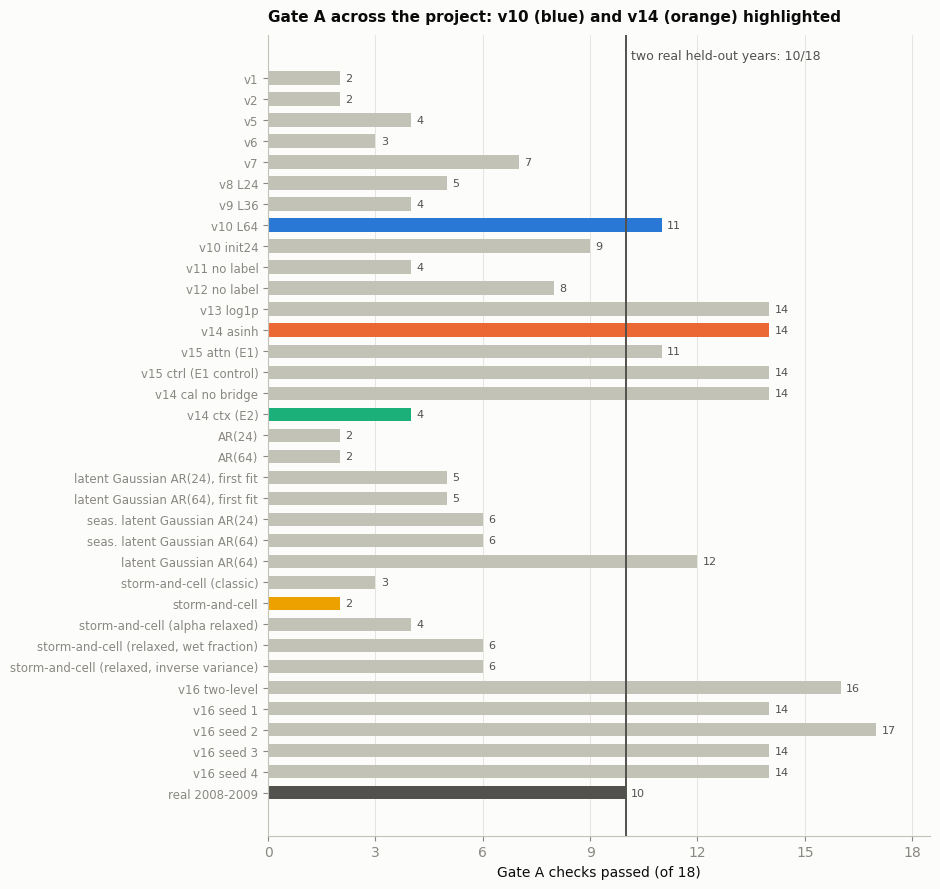

In [3]:
order = [n for n in META.index if n in GATE] + ['real 2008-2009']
fig, ax = plt.subplots(figsize=(9.5, 9))
y = np.arange(len(order))[::-1]
vals = [TALLY[n] for n in order]
ax.barh(y, vals, color=[col(n) for n in order], height=0.64)
real_t = TALLY['real 2008-2009']
ax.axvline(real_t, color=REAL, lw=1.4)
ax.text(real_t + 0.15, y[0] + 0.9, f'two real held-out years: {real_t}/18', color=REAL, fontsize=9)
for yy, n, v in zip(y, order, vals):
    ax.text(v + 0.15, yy, str(v), va='center', fontsize=8, color=REAL)
ax.set_yticks(y); ax.set_yticklabels([lab(n) for n in order], fontsize=8.5)
ax.set_xlim(0, 18.5); ax.set_xticks(range(0, 19, 3)); ax.set_xlabel('Gate A checks passed (of 18)')
ax.grid(axis='y', visible=False)
ax.set_title('Gate A across the project: v10 (blue) and v14 (orange) highlighted', pad=10)
plt.tight_layout(); plt.show()

In [4]:
gm = pd.DataFrame(GATE).T[list(next(iter(GATE.values())).keys())]
gm = gm.loc[[n for n in order if n in gm.index]].replace({True: '✓', False: '·'})
gm.insert(0, 'passed', TALLY.reindex(gm.index).astype(int))
gm.index = [lab(n) for n in gm.index]
gm

,passed,T1 volume,T1 zero fraction,T1 wet spell,T1 dry spell,T2 P99 wet,T2 P99.9 wet,T2 max,T2 JSD hourly,T2 KS hourly,T3 lag-1 ACF,T3 hourly ACF,T3 storm duration,T3 storm count,T3 storm volume,T4 daily max,T4 IDF (all 15 cells),T5 monthly cycle,T5 diurnal cycle
v1,2,·,✓,·,·,·,·,✓,·,·,·,·,·,·,·,·,·,·,·
v2,2,·,✓,·,·,·,·,✓,·,·,·,·,·,·,·,·,·,·,·
v5,4,·,✓,·,·,✓,·,·,·,✓,✓,·,·,·,·,·,·,·,·
v6,3,·,✓,·,·,·,·,·,·,✓,✓,·,·,·,·,·,·,·,·
v7,7,✓,✓,·,·,✓,✓,✓,·,✓,✓,·,·,·,·,·,·,·,·
v8 L24,5,✓,✓,·,·,·,✓,·,·,✓,✓,·,·,·,·,·,·,·,·
v9 L36,4,·,✓,·,·,✓,✓,·,·,✓,·,·,·,·,·,·,·,·,·
v10 L64,11,·,✓,·,✓,✓,✓,✓,✓,✓,✓,✓,·,✓,✓,·,·,·,·
v10 init24,9,✓,·,·,✓,·,·,✓,✓,✓,✓,·,·,✓,✓,✓,·,·,·
v11 no label,4,·,✓,·,·,·,✓,·,·,✓,✓,·,·,·,·,·,·,·,·


**Findings.**
* The clean-split diffusion line climbs from **5/18 (v8)** to **11/18 (v10)** to **14/18
  (v13, v14, v15_ctrl, v14 calendar without bridges)**. Early prototypes (v1–v7) scored 2–7.
  The first latent Gaussian baselines score 5–7/18; refitted to match rain occurrence, the latent Gaussian AR scores
  **12/18** (§5.4). The storm-and-cell model scores only **2/18**, even though
  it gets long storms right (§3.3): most Gate A checks are about fine-scale texture, where it is
  weak. Gate A therefore favours what diffusion is good at; §4.1 and §5.4 give the balanced view.
* **The two real held-out years pass only 10/18.** They fail dry-spell length, the 5-minute
  maximum, the hourly JSD, storm count (610 vs 697 per year), storm volume, extremes (9/15 IDF cells
  from just 2 years), the monthly cycle (r = 0.77) and the diurnal cycle (r = 0.54). Some Gate A
  bands are therefore tighter than real year-to-year variation, and the **diurnal check fails even
  for real rain**. Gate A remains useful for ranking versions, but a
  "pass" threshold should be set against this real-vs-real calibration (§4.1 does that).
* No version passes all extremes cells or the diurnal check. Only **v14 calendar without
  bridges** passes the monthly check (§3.6).

### 2.1 Tier 6: storms at the sewer's scale (added 2026-10-04)

The sewer fills its tanks over whole storms (they take about 45 h to drain) and smooths 5-minute
detail, so Tier 6 scores storms the way flood-control's sewer check counts them: wet steps with
no dry run of 2 h or more between them. Three checks (`tier6()` in `eval_suite.py`; bands are the
95% range of a 10-year resample of real years against the 8-year reference, rounded out):
**S1** storms >= 10 mm per year (0.85–1.15), **S2** share of rain in storms longer than 320 min
(0.90–1.10), **S3** mean depth of the largest 1.25 storms per year, i.e. the top 10 of the 8
reference years (0.70–1.45). Scored apart from the 18 checks above, which keep their meaning.

In [5]:
T6 = E['tier6']
t6rows = ['real 2008-2009', 'v8', 'v10', 'v12', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal', 'v14_ctx',
          'bartlett_lewis', 'arima_copula_len64', 'arima_copula_occ_len64',
          'v16', 'v16_m1', 'v16_m2', 'v16_m3', 'v16_m4']
cols6 = {'storms_ge10mm_yr': 'storms >= 10 mm /yr', 'rain_in_320min_pct': '% rain in storms > 320 min',
         'top10_storm_mm': 'top-10 depth (mm)', 'storms_320min_yr': 'storms > 320 min /yr', 'max_storm_mm': 'largest (mm)'}
t6 = pd.DataFrame({n: E['hydro'][n] for n in ['real 2000-2007'] + t6rows}).T[list(cols6)].astype(float)
for n in t6rows:
    for k, v in T6[n].items():
        t6.loc[n, k.split()[0]] = '✓' if v else '·'
    t6.loc[n, 'Tier 6'] = f'{sum(T6[n].values())}/3'
t6.index = [lab(n) for n in t6.index]
t6.rename(columns=cols6).fillna('')

,storms >= 10 mm /yr,% rain in storms > 320 min,top-10 depth (mm),storms > 320 min /yr,largest (mm),S1,S2,S3,Tier 6
real 2000-2007,15.750,64.650,37.517,74.750,55.545,,,,
real 2008-2009,15.500,61.280,71.756,58.500,101.872,✓,✓,·,2/3
v8 L24,5.300,8.927,17.922,17.400,22.178,·,·,·,0/3
v10 L64,7.400,24.960,21.499,32.600,28.573,·,·,·,0/3
v12 no label,9.000,24.180,24.088,31.600,36.940,·,·,·,0/3
v13 log1p,7.500,23.707,20.983,33.800,25.243,·,·,·,0/3
v14 asinh,8.500,23.831,22.507,36.300,27.288,·,·,·,0/3
v15 ctrl (E1 control),7.700,23.350,21.002,35.400,27.477,·,·,·,0/3
v15 attn (E1),7.900,23.134,24.788,35.700,31.319,·,·,·,0/3
v14 cal no bridge,7.602,24.553,24.786,35.009,42.798,·,·,·,0/3


**Findings.**
* **No version before v16 passes S1 or S2.** The diffusion versions make about half the real
  number of storms >= 10 mm and put a quarter of the rain, not two thirds, into long storms:
  blocks are generated independently, so showers never cluster into long storms (the Sept 28
  architecture audit). Only S3, the noisiest check, is passed near its lower edge (storm-and-cell
  0.74 and 0.81). The storm-and-cell model's long
  storms are unbroken wet runs, while real long storms are clusters of showers with short breaks.
* **v16 (two-level) passes 3/3 on four of five seeds** and 2/3 on the driest (seed 1, 641 mm/yr:
  13.2 storms >= 10 mm per year, ratio 0.84), while keeping Gate A at 14–17/18 (v14 14/18). A
  storm model fitted to the 2000–2007 storms sets when it rains, for how long and how much; v14's
  own 5-minute rain fills each storm (`regime_training/generate_two_level.py`; diary, Oct 4).
* The two real held-out years pass S1 and S2 and fail S3: two years have only two "top" storms,
  one of them 102 mm. S3 needs about ten years to mean anything.

## 3. Hydrology

### 3.1 Water balance and occurrence

Total rain decides how full the system gets; *how* rain switches on and off decides the
filling rhythm. "Single-step showers" = wet runs lasting one 5-minute step (a sign of broken-up,
flickering rain); "very light" = 0.005–0.02 mm steps, typical of storm edges.

In [6]:
rows = ['real 2000-2007', 'real 2008-2009'] + [n for n in KEY if n in H.index] + [b for b in BASE if b not in KEY]
t31 = H.loc[rows, ['volume_mm_yr', 'zero_pct', 'p_wet_after_wet', 'single_step_showers_pct', 'very_light_pct',
                   'wet_spell_min', 'dry_spell_h']].astype(float)
t31.columns = ['rain mm/yr', 'dry steps %', 'P(wet | wet)', 'single-step showers %', 'very light steps %',
               'mean wet spell (min)', 'mean dry spell (h)']
t31.index = [lab(n) for n in rows]
t31.round(3)

,rain mm/yr,dry steps %,P(wet | wet),single-step showers %,very light steps %,mean wet spell (min),mean dry spell (h)
real 2000-2007,709.577,90.796,0.844,38.062,3.138,31.975,5.257
real 2008-2009,708.350,91.619,0.845,40.036,2.669,32.155,5.856
v10 L64,649.240,91.751,0.819,40.433,2.761,27.690,5.133
v13 log1p,675.610,91.298,0.831,39.391,2.997,29.589,5.174
v14 asinh,716.120,91.010,0.836,38.294,3.068,30.467,5.141
v15 ctrl (E1 control),699.852,90.995,0.838,38.575,3.058,30.821,5.190
v15 attn (E1),674.959,91.280,0.828,38.347,3.137,29.123,5.080
v14 cal no bridge,697.651,91.092,0.838,38.143,3.030,30.798,5.249
v14 ctx (E2),346.415,95.192,0.852,39.207,1.654,33.799,11.152
storm-and-cell,634.928,93.361,0.926,7.412,1.752,67.179,15.743


**Findings.**
* v14 gets the water balance right (716 vs 710 mm/yr) and the dry fraction within 0.2 pp. v10 was
  8.5% dry-biased. The gain comes from **very light steps** (v10 2.76%, v14 3.07%, real 3.14%):
  under the old StandardScaler the model could not place storm edges above the 0.005 mm threshold.
* Diffusion matches the real share of single-step showers (38%). **The first latent Gaussian fits are badly
  broken up: 75% single-step showers and 7-minute wet spells** (real 32), even though their total
  volume and dry fraction are perfect (they are fitted to the marginals). The cause is the fit:
  their latent lag-1 correlation is 0.47 where real occurrence needs 0.976. The occurrence-matched
  refit sits on the real values (39% single-step showers, 32.6-minute wet spells, 5.4-hour dry
  spells). Gaussian AR rains on half of all steps.
* E2 halves the rain (346 mm/yr, 95% dry): the dry bias examined in §5.3.
* The **storm-and-cell model** errs the other way from the latent Gaussian models: too few, too long, too smooth
  showers (7% single-step, 67-minute wet spells, 16-hour dry spells, 93% dry steps). Its total
  (635 mm/yr) is low partly by chance: this seed-42 draw is the driest of 22 seeds tried
  (676–754 mm/yr otherwise; the fitted monthly means match the real ones exactly).

### 3.2 Intensity

The wet-step exceedance curve: how heavy is the rain at each level of rarity. The right end is
what overflows.

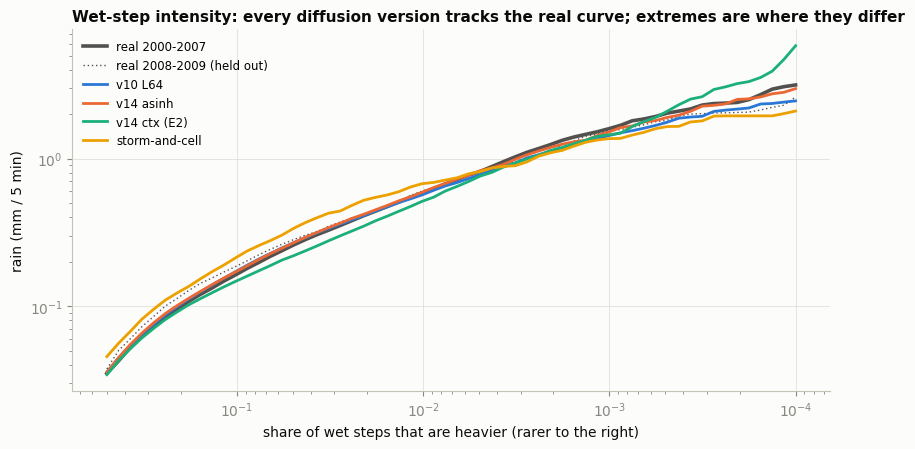

,mean wet,P50,P90,P99,P99.9,max 5-min,max 1-h,Wasserstein (mm)
real 2000-2007,0.073,0.035,0.165,0.588,1.598,5.555,18.205,0.000
real 2008-2009,0.080,0.038,0.188,0.602,1.549,3.995,12.022,0.008
v10 L64,0.075,0.036,0.174,0.571,1.437,4.612,12.988,0.003
v13 log1p,0.074,0.035,0.167,0.572,1.531,6.235,18.175,0.002
v14 asinh,0.076,0.036,0.173,0.597,1.528,6.357,16.203,0.003
v15 ctrl (E1 control),0.074,0.035,0.167,0.568,1.481,5.805,15.293,0.002
v15 attn (E1),0.074,0.033,0.168,0.607,1.627,6.396,22.903,0.002
v14 cal no bridge,0.075,0.036,0.168,0.586,1.461,6.358,20.399,0.002
v14 ctx (E2),0.069,0.034,0.149,0.516,1.452,9.042,22.451,0.007
storm-and-cell,0.091,0.045,0.215,0.677,1.366,2.770,21.698,0.020


In [7]:
qp = 1 - ev.QPROBS                                   # exceedance probability among wet steps
fig, ax = plt.subplots(figsize=(8.5, 4.6))
show = ['v10', 'v14', 'v14_ctx', 'bartlett_lewis']
ax.plot(qp, E['curves']['real 2000-2007']['wet_quantiles'], color=REAL, lw=2.6, label='real 2000-2007')
ax.plot(qp, E['curves']['real 2008-2009']['wet_quantiles'], color=REAL, lw=1, ls=(0, (1, 2)), label='real 2008-2009 (held out)')
for n in show:
    ax.plot(qp, E['curves'][n]['wet_quantiles'], color=col(n), label=lab(n))
ax.set_xscale('log'); ax.set_yscale('log'); ax.invert_xaxis()
ax.set_xlabel('share of wet steps that are heavier (rarer to the right)'); ax.set_ylabel('rain (mm / 5 min)')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_title('Wet-step intensity: every diffusion version tracks the real curve; extremes are where they differ')
plt.tight_layout(); plt.show()

t32 = H.loc[rows, ['mean_wet_mm', 'p50_wet', 'p90_wet', 'p99_wet', 'p999_wet', 'max_5min', 'max_1h', 'w1_wet_5min']].astype(float)
t32.columns = ['mean wet', 'P50', 'P90', 'P99', 'P99.9', 'max 5-min', 'max 1-h', 'Wasserstein (mm)']
t32.index = [lab(n) for n in rows]
t32.round(3)

**Findings.** Intensity marginals are the easiest part: every clean diffusion version and the
latent Gaussian baselines sit within the real curve up to P99.9 (Wasserstein distance 0.003–0.005 mm,
inside the real 2-year range 0.003–0.009, §4.1). v13/v14 produce 5-minute peaks up to 6.2–6.4 mm,
above the observed record (5.6 mm): the model extrapolates beyond the training maximum, which is
useful for stress-testing a controller *if* the shape of those events is plausible. E2 rains less
but harder when it does (peak 9.0 mm; its upper tail lies above the real curve). The
storm-and-cell model's tail is too light (peak 2.8 mm, P99.9 1.37 vs 1.60 mm), the textbook
weakness of this family at 5 minutes, even with the intensity variant designed for it.

### 3.3 Storms and the block-boundary cliff

A storm = a run of wet steps lasting at least 15 minutes. The survival ratio
P(duration > d) generated ÷ real shows, for each duration *d*, what fraction of real storms of
that length the model produces. Every model before E2 builds its series from independent blocks
(2 h for v8, 5h20 for v10–v15), and a storm can only outlast a block by coincidence.

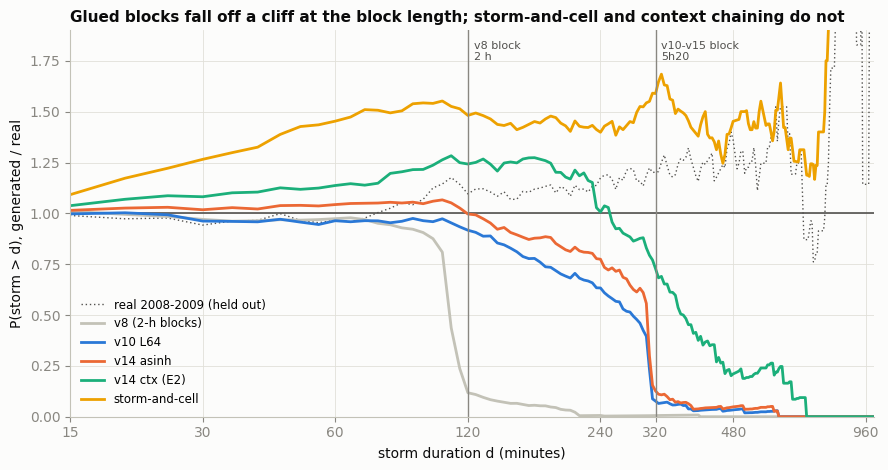

,storms/yr,mean duration (min),mean depth (mm),mean peak (mm),survival ratio 2 h,survival ratio 4 h,survival ratio 5h20,storms > 5h20 /yr,% of rain in them
real 2000-2007,697.125,61.823,0.999,0.150,1.000,1.000,1.000,14.25,21.437
real 2008-2009,610.000,64.254,1.141,0.160,1.096,1.175,1.203,15.00,27.154
v10 L64,699.800,54.104,0.907,0.151,0.917,0.633,0.077,1.10,1.627
v13 log1p,712.100,56.798,0.930,0.149,1.008,0.728,0.117,1.70,2.177
v14 asinh,733.500,57.324,0.959,0.151,0.997,0.775,0.127,1.90,2.198
v15 ctrl (E1 control),730.300,57.839,0.941,0.149,1.016,0.789,0.127,1.90,2.068
v15 attn (E1),747.200,54.316,0.886,0.149,0.881,0.562,0.079,1.20,1.396
v14 cal no bridge,726.491,57.511,0.943,0.150,0.991,0.797,0.094,1.40,1.888
v14 ctx (E2),352.625,64.614,0.966,0.143,1.243,1.007,0.728,5.25,10.946
storm-and-cell,424.800,80.366,1.463,0.160,1.482,1.399,1.589,13.80,8.909


In [8]:
ref_s = E['curves']['real 2000-2007']['surv']
d_min = np.arange(1, 200) * 5
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(1, color=REAL, lw=1.2)
ratio = lambda n: np.divide(E['curves'][n]['surv'], ref_s, out=np.full_like(ref_s, np.nan), where=ref_s > 0)
ax.plot(d_min, ratio('real 2008-2009'), color=REAL, lw=1, ls=(0, (1, 2)), label='real 2008-2009 (held out)')
ax.plot(d_min, ratio('v8'), color=CTX, lw=2, label='v8 (2-h blocks)')
for n in ['v10', 'v14', 'v14_ctx', 'bartlett_lewis']:
    ax.plot(d_min, ratio(n), color=col(n), label=lab(n))
for L, txt in [(120, 'v8 block\n2 h'), (320, 'v10-v15 block\n5h20')]:
    ax.axvline(L, color=MUTED, lw=1)
    ax.text(L * 1.03, 1.85, txt, fontsize=8, color=REAL, va='top')
ax.set_xscale('log'); ax.set_ylim(0, 1.9); ax.set_xlim(15, 1000)
ax.set_xticks([15, 30, 60, 120, 240, 320, 480, 960]); ax.set_xticklabels(['15', '30', '60', '120', '240', '320', '480', '960'])
ax.minorticks_off()
ax.set_xlabel('storm duration d (minutes)'); ax.set_ylabel('P(storm > d), generated / real')
ax.legend(fontsize=8.5, loc='lower left')
ax.set_title('Glued blocks fall off a cliff at the block length; storm-and-cell and context chaining do not')
plt.tight_layout(); plt.show()

t33 = H.loc[rows, ['storms_yr', 'storm_dur_min', 'storm_depth_mm', 'storm_peak_mm', 'surv_ratio_120min', 'surv_ratio_240min',
                   'surv_ratio_320min', 'long_storms_yr', 'long_storm_rain_pct']].astype(float)
t33.columns = ['storms/yr', 'mean duration (min)', 'mean depth (mm)', 'mean peak (mm)', 'survival ratio 2 h',
               'survival ratio 4 h', 'survival ratio 5h20', 'storms > 5h20 /yr', '% of rain in them']
t33.index = [lab(n) for n in rows]
t33.round(3)

**Findings.**
* The survival ratio stays near 1 up to about three-quarters of the block length, then
  **collapses at exactly the block length**: v8 at 2 h, v10–v15 at 5h20. v14 makes **1.9 storms/yr
  longer than 5h20 (real 14.25) carrying 2.2% of the rain (real 21.4%)**.
* Transform, labels and attention move the curve *below* the wall (v14 at 4 h: 0.78 vs v10 0.63)
  but not the wall itself. **Only E2 moves it: 0.73 at 5h20 (real held-out years: 1.2), 5.3
  storms/yr, 10.9% of rain in them.**
* The first latent Gaussian fits produce no storm longer than about 2 h at all. The
  occurrence-matched latent Gaussian AR makes 15.8 storms/yr longer than 5h20 (survival ratio 1.15),
  but they are too heavy: 44% of its rain falls in them (real 21.4%).
* **The storm-and-cell model also has about the right number of long storms** (13.8/yr; its
  survival ratio rises *above* 1 beyond 5 hours), because its storms are built from a storm
  process rather than glued blocks. But they are gentle: they carry 8.9% of its rain (real 21.4%).

### 3.4 Extremes (annual maxima, IDF)

For each duration (15 min to 24 h) the annual maximum rainfall is fitted with a Gumbel
distribution, and its 2-, 5- and 10-year levels are compared with the real ones. Blue = too
weak, red = too strong, grey = right.

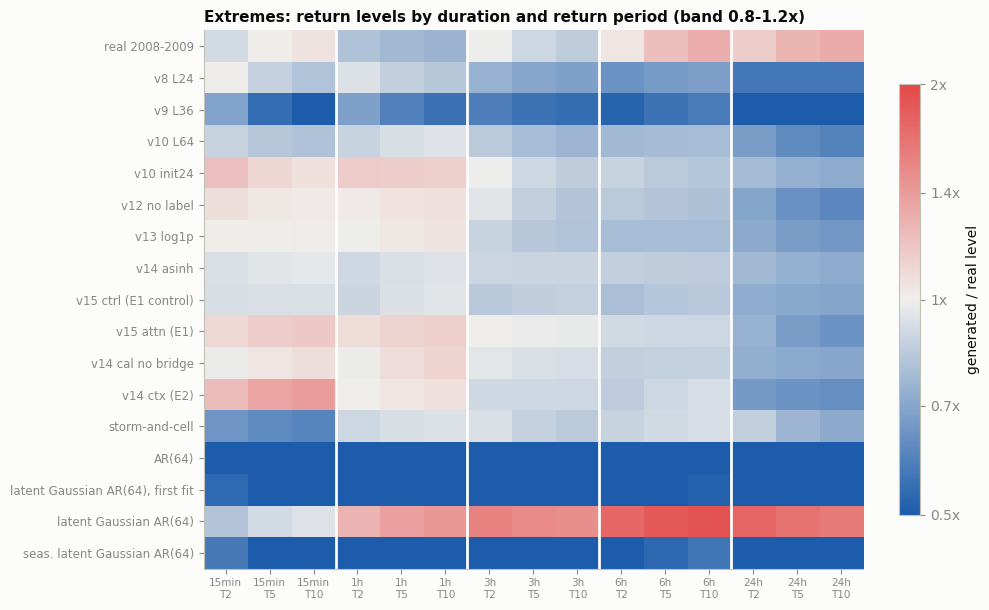

,cells in band,15min T2,15min T5,15min T10,1h T2,1h T5,1h T10,3h T2,3h T5,3h T10,6h T2,6h T5,6h T10,24h T2,24h T5,24h T10
real 2008-2009,9,0.91,1.01,1.04,0.81,0.78,0.76,0.99,0.90,0.85,1.04,1.22,1.31,1.16,1.27,1.32
v8 L24,6,1.01,0.87,0.82,0.94,0.86,0.83,0.75,0.71,0.70,0.65,0.67,0.69,0.57,0.57,0.57
v9 L36,0,0.70,0.54,0.48,0.69,0.60,0.56,0.59,0.56,0.54,0.52,0.56,0.58,0.47,0.47,0.47
v10 L64,7,0.88,0.83,0.81,0.88,0.92,0.94,0.85,0.79,0.77,0.78,0.78,0.79,0.68,0.63,0.60
v10 init24,11,1.21,1.11,1.07,1.16,1.15,1.14,0.99,0.90,0.85,0.88,0.84,0.82,0.79,0.75,0.73
v12 no label,12,1.07,1.03,1.02,1.02,1.05,1.06,0.95,0.86,0.82,0.84,0.82,0.81,0.71,0.64,0.62
v13 log1p,9,1.01,1.01,1.01,0.99,1.03,1.05,0.88,0.84,0.82,0.79,0.79,0.79,0.73,0.68,0.67
v14 asinh,12,0.93,0.95,0.96,0.90,0.93,0.95,0.89,0.89,0.88,0.86,0.85,0.85,0.78,0.74,0.73
v15 ctrl (E1 control),11,0.93,0.93,0.93,0.89,0.93,0.96,0.84,0.86,0.87,0.80,0.83,0.84,0.73,0.72,0.71
v15 attn (E1),12,1.10,1.15,1.17,1.08,1.12,1.14,1.00,0.98,0.98,0.90,0.90,0.90,0.75,0.68,0.65


In [9]:
idf_rows = ['real 2008-2009', 'v8', 'v9', 'v10', 'e1_v10ckpt24', 'v12', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal',
            'v14_ctx'] + BASE
cells_ = list(E['idf']['v14'].keys())
M = np.array([[E['idf'][n].get(k, np.nan) for k in cells_] for n in idf_rows])
cmap = mcolors.LinearSegmentedColormap.from_list('div', ['#1c5cab', '#f0efec', '#e34948'])
fig, ax = plt.subplots(figsize=(10, 6.2))
im = ax.imshow(np.log2(M), cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cells_))); ax.set_xticklabels([f'{d}\nT{t}' for d, t in cells_], fontsize=7.5)
ax.set_yticks(range(len(idf_rows))); ax.set_yticklabels([lab(n) for n in idf_rows], fontsize=8.5)
ax.grid(False)
for x in [2.5, 5.5, 8.5, 11.5]:
    ax.axvline(x, color=SURFACE, lw=2)
cb = plt.colorbar(im, ax=ax, ticks=np.log2([0.5, 0.71, 1, 1.41, 2]), fraction=0.03)
cb.ax.set_yticklabels(['0.5x', '0.7x', '1x', '1.4x', '2x']); cb.set_label('generated / real level')
ax.set_title('Extremes: return levels by duration and return period (band 0.8-1.2x)')
plt.tight_layout(); plt.show()

tidf = pd.DataFrame(M, index=[lab(n) for n in idf_rows], columns=[f'{d} T{t}' for d, t in cells_]).round(2)
tidf.insert(0, 'cells in band', [int(np.nansum((M[i] >= .8) & (M[i] <= 1.2))) for i in range(len(idf_rows))])
tidf

**Findings.** Up to 6 hours v14 is in band (12/15 cells); every diffusion version is **weak at
24 h (0.6–0.8×)**, the signature of the missing long storms. The held-out real years pass only 9
cells (two years make a poor Gumbel fit), so the 24-h gap, not the scatter elsewhere, is the
real signal. E2 overshoots short extremes (15 min: 1.2–1.4×) and stays weak at 24 h (0.64–0.67×).
The first latent Gaussian fits fail every cell (0.4–0.6×) and Gaussian AR is far worse (0.05–0.44×):
they cannot build heavy multi-hour accumulations. The occurrence-matched latent Gaussian AR fails the
other way: right at 15 minutes (0.82–0.94×) but too heavy from 1 hour (1.3–1.9×), 3/15 cells. The storm-and-cell model passes 10/15 cells: good at
1–6 hours, weak at 15 minutes (0.6×) and at 24 hours (0.7–0.9×).

### 3.5 Structure across time scales

Two views of persistence: the autocorrelation of hourly totals, and how the variance of rainfall
totals grows as they are aggregated from 5 minutes to a week (shown as generated ÷ real; 1 =
right at that scale).

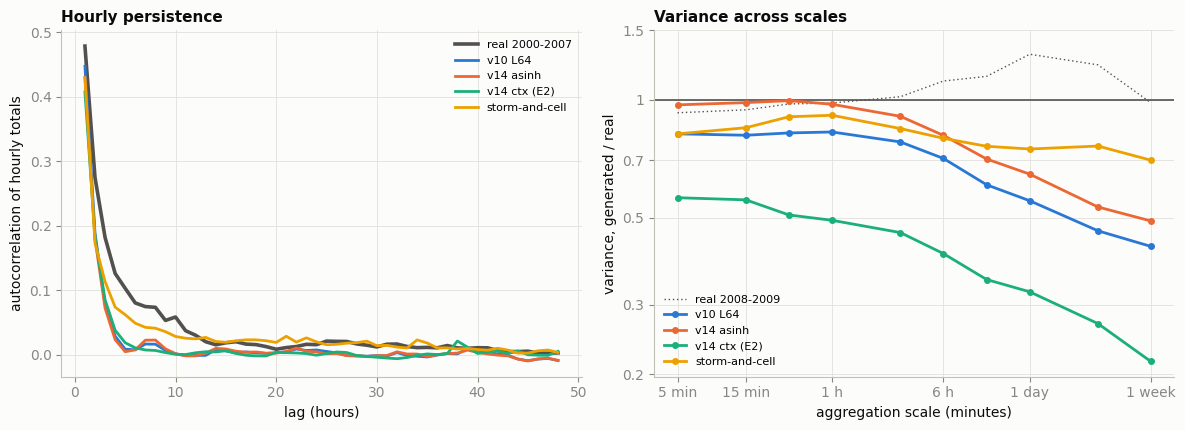

,lag-1 ACF (5 min),hourly ACF RMSE (1-24 h),variance-scaling error (log10 RMSE)
real 2000-2007,0.852,0.000,0.000
real 2008-2009,0.862,0.041,0.054
v10 L64,0.838,0.050,0.207
v13 log1p,0.852,0.055,0.190
v14 asinh,0.864,0.051,0.155
v15 ctrl (E1 control),0.860,0.055,0.188
v15 attn (E1),0.853,0.056,0.178
v14 cal no bridge,0.862,0.054,0.171
v14 ctx (E2),0.820,0.051,0.424
storm-and-cell,0.889,0.034,0.100


In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
lags = np.arange(49)
a1.plot(lags[1:], E['curves']['real 2000-2007']['acf_h'][1:], color=REAL, lw=2.6, label='real 2000-2007')
for n in ['v10', 'v14', 'v14_ctx', 'bartlett_lewis']:
    a1.plot(lags[1:], E['curves'][n]['acf_h'][1:], color=col(n), label=lab(n))
a1.set_xlabel('lag (hours)'); a1.set_ylabel('autocorrelation of hourly totals'); a1.legend(fontsize=8)
a1.set_title('Hourly persistence')
sc_min = np.array(ev.SCALES) * 5
ref_v = E['curves']['real 2000-2007']['var_scale']
a2.axhline(1, color=REAL, lw=1.2)
a2.plot(sc_min, E['curves']['real 2008-2009']['var_scale'] / ref_v, color=REAL, lw=1, ls=(0, (1, 2)), label='real 2008-2009')
for n in ['v10', 'v14', 'v14_ctx', 'bartlett_lewis']:
    a2.plot(sc_min, E['curves'][n]['var_scale'] / ref_v, color=col(n), marker='o', ms=4, label=lab(n))
a2.set_xscale('log'); a2.set_yscale('log'); a2.set_xlabel('aggregation scale (minutes)')
a2.set_yticks([0.2, 0.3, 0.5, 0.7, 1, 1.5]); a2.set_yticklabels(['0.2', '0.3', '0.5', '0.7', '1', '1.5']); a2.minorticks_off()
a2.set_xticks([5, 15, 60, 360, 1440, 10080]); a2.set_xticklabels(['5 min', '15 min', '1 h', '6 h', '1 day', '1 week'])
a2.set_ylabel('variance, generated / real'); a2.set_title('Variance across scales'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

t35 = H.loc[rows, ['acf1', 'hourly_acf_rmse', 'var_scaling_rmse']].astype(float)
t35.columns = ['lag-1 ACF (5 min)', 'hourly ACF RMSE (1-24 h)', 'variance-scaling error (log10 RMSE)']
t35.index = [lab(n) for n in rows]
t35.round(3)

**Findings.** v14 matches the real variance up to about an hour, then loses it as totals are
aggregated: about 65% of real at 1 day and 50% at a week. That is the long-storm deficit seen as
variance; v10 is lower throughout (scaling error 0.21 vs v14 0.16). Its hourly autocorrelation
also decays too fast beyond a few hours (RMSE 0.05; real 2-year samples 0.02–0.04). **The first latent Gaussian
AR baselines are better at hourly persistence (RMSE 0.024–0.029 at L = 64)** but lose 70% of the
variance by 1 hour (scaling error 0.45–0.56): they spread rain into weak, flickering showers.
The occurrence-matched latent Gaussian AR has the opposite problem: rain persists too long (hourly ACF RMSE
0.074, 5-minute lag-1 ACF 0.93 vs 0.85), and its scaling error is 0.20. E2
has about half the variance at every scale, because it makes half the rain. **The storm-and-cell
models are best on both views**: hourly persistence inside the real range (RMSE 0.024–0.034) and
the smallest variance-scaling errors (0.09–0.10).

### 3.6 Seasons and year-to-year variability

Calendar assembly places blocks by time of year; Markov assembly samples regimes with no
calendar, so only calendar versions should reproduce the seasonal cycle.

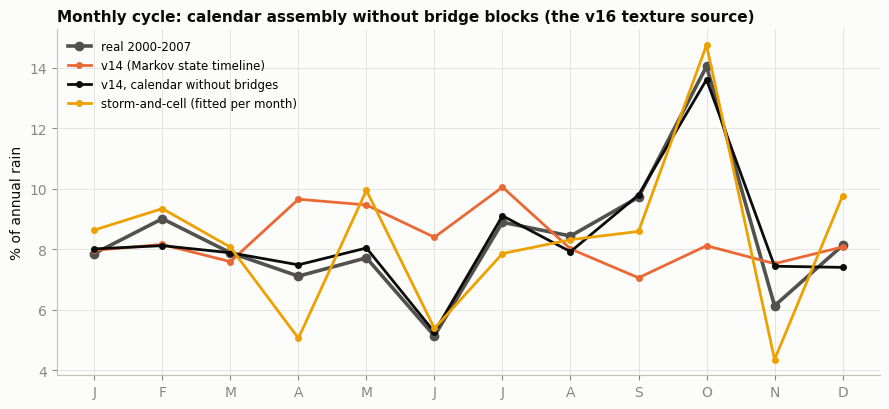

,monthly cycle r,diurnal cycle r,year-to-year CV
real 2008-2009,0.766,0.537,0.095
v10 L64,-0.060,-0.280,0.122
v14 asinh,-0.107,-0.314,0.122
v14 cal no bridge,0.965,-0.113,0.114
v14 ctx (E2),-0.593,-0.180,0.145
v16 two-level,0.928,0.486,0.080
storm-and-cell,0.883,0.479,0.112
seas. latent Gaussian AR(64),0.233,-0.110,0.097
latent Gaussian AR(64),0.295,0.237,0.095


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2))
mon = np.arange(1, 13)
norm = lambda v: v / v.sum() * 100
ax.plot(mon, norm(E['curves']['real 2000-2007']['monthly']), color=REAL, lw=2.6, marker='o', label='real 2000-2007')
ax.plot(mon, norm(E['curves']['v14']['monthly']), color=col('v14'), marker='o', ms=4, label='v14 (Markov state timeline)')
ax.plot(mon, norm(E['curves']['v14_nobridge_cal']['monthly']), color=INK, marker='o', ms=4, label='v14, calendar without bridges')
ax.plot(mon, norm(E['curves']['bartlett_lewis']['monthly']), color=col('bartlett_lewis'),
        marker='o', ms=4, label=lab('bartlett_lewis') + ' (fitted per month)')
ax.set_xticks(mon); ax.set_xticklabels(list('JFMAMJJASOND')); ax.set_ylabel('% of annual rain')
ax.legend(fontsize=8.5); ax.set_title('Monthly cycle: calendar assembly without bridge blocks (the v16 texture source)')
plt.tight_layout(); plt.show()

srows = ['real 2008-2009', 'v10', 'v14', 'v14_nobridge_cal', 'v14_ctx', 'v16', 'bartlett_lewis',
         'arima_copula_seas_markov_len64', 'arima_copula_occ_len64']
t36 = H.loc[srows, ['monthly_r', 'diurnal_r', 'interannual_cv']].astype(float)
t36.columns = ['monthly cycle r', 'diurnal cycle r', 'year-to-year CV']
t36.index = [lab(n) for n in srows]
t36.round(3)

**Findings.** Only calendar assembly, which replays the training years' state sequence, gives
the HMM-conditioned models the right seasons. Without bridge blocks (`--bridge_blocks 0`) v14
reaches **monthly r = 0.97**, as predicted before the run (Sept 30). With bridge blocks the seasons
drifted: each bridge added time the calendar did not count, pushing them 39 days late by year 10
(v14 with bridges: r = 0.62). Calendar versions changed no storm or extreme statistic and, with
bridges, cost 1–4 Gate A checks, so they are no longer tabulated (diary, Oct 8). v14 without
bridges stays because it is v16's texture source; v16 passes the monthly check (r = 0.93).
Transition-sampled versions sit near r = 0; the seasonal latent Gaussian AR (Markov) at 0.23.
The diurnal cycle fails everywhere, including for the real held-out years (0.54): at 5-minute
resolution it is weak and noisy, and the check is probably too strict. Year-to-year variability
of diffusion (CV 0.12) is above the real training years' (0.085): generated years differ a bit
more than real ones. The storm-and-cell model, fitted month by month, reaches r = 0.88 without any
calendar machinery, and has the most realistic diurnal cycle of any model (0.48; real held-out
years 0.54).

### 3.7 The official German heavy-rain table (KOSTRA-DWD-2020)

KOSTRA is the German Weather Service's design-rainfall table: for every 5 km grid cell, how much
rain falls in 5 minutes to 7 days at a 1- to 100-year return period, fitted to 1951–2020. It is what
German engineers design sewers with. The Astlingen rain is four 5-minute gauge series from the
Erftverband, so the comparison uses the KOSTRA cells under the Erftverband's own stations (the
exact gauge sites are not published; `scripts/kostra_compare.py`).

KOSTRA describes **single points**, while this project's "real" series is the **average of the four
gauges**, so the comparison has three steps: KOSTRA vs the real gauges, the gauges vs their average
(how much averaging softens peaks), and the average vs the models.

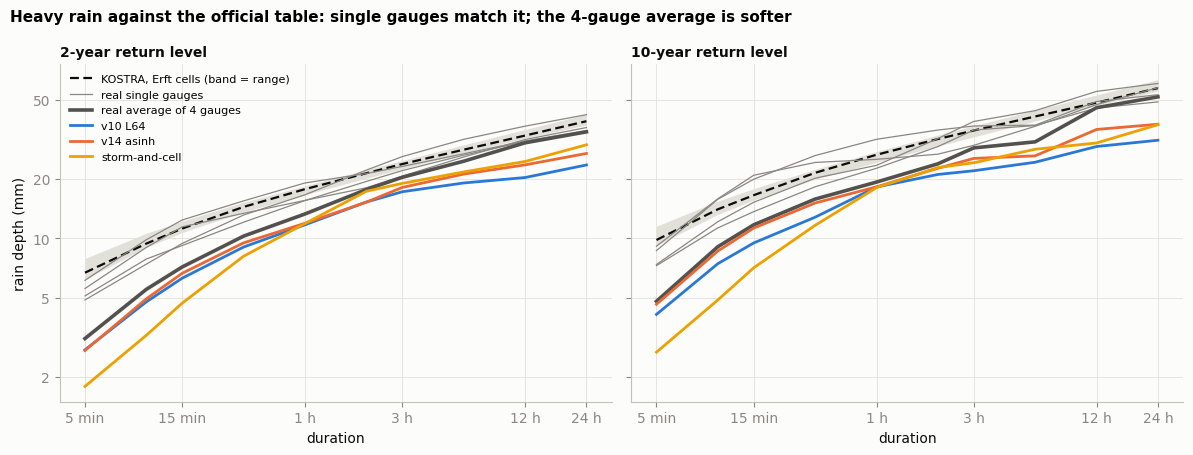

KOSTRA median (mm)  gauges / KOSTRA  average / gauges  v14 / real average  storm-and-cell / real average  v10 / real average
duration_min T                                                                                                                               
5            2                  6.7             0.81              0.57                0.87                           0.57                0.88
             10                 9.8             0.83              0.59                0.97                           0.55                0.86
10           2                  9.4             0.91              0.65                0.90                           0.59                0.86
             10                14.0             0.98              0.66                0.95                           0.54                0.82
15           2                 11.2             0.95              0.68                0.93                           0.66                0.88
             10                16.5             1.05              0.67                0.96                           0.61                0.81
30           2                 14.4             0.94              0.76                0.92                           0.79                0.88
             10                21.4             1.03              0.71                0.96                           0.74                0.81
60           2                 17.7             0.94              0.80                0.90                           0.89                0.88
             10                26.4             0.97              0.75                0.95                           0.94                0.94
120          2                 21.3             0.95              0.87                0.86                           0.98                0.86
             10                31.7             0.97              0.77                0.95                           0.96                0.88
180          2                 23.7             0.96              0.89                0.89                           0.93                0.85
             10                35.0             1.00              0.81                0.88                           0.84                0.77
360          2                 28.0             0.98              0.89                0.86                           0.88                0.78
             10                41.2             0.94              0.79                0.85                           0.92                0.79
720          2                 33.0             0.99              0.93                0.77                           0.80                0.67
             10                48.4             1.02              0.93                0.78                           0.66                0.64
1440         2                 39.0             0.95              0.93                0.78                           0.86                0.68
             10                57.3             0.96              0.94                0.73                           0.72                0.60

In [12]:
K = pd.read_json(os.path.join('..', 'results', 'kostra', 'kostra_comparison.json'))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, T_ in zip(axes, [2, 10]):
    k = K[K['T'] == T_].sort_values('duration_min')
    d = k.duration_min.values
    ax.fill_between(d, k.kostra_min, k.kostra_max, color=GRID, lw=0)
    ax.plot(d, k.kostra_median, color=INK, lw=1.6, ls=(0, (4, 2)), label='KOSTRA, Erft cells (band = range)')
    for i in range(1, 5):
        ax.plot(d, k[f'gauge {i}'], color=MUTED, lw=0.9, label='real single gauges' if i == 1 else None)
    ax.plot(d, k['real average of 4 gauges'], color=REAL, lw=2.6, label='real average of 4 gauges')
    ax.plot(d, k['v10 (previous best)'], color=col('v10'), label=lab('v10'))
    ax.plot(d, k['v14 (current best)'], color=col('v14'), label=lab('v14'))
    ax.plot(d, k['storm-and-cell model'], color=col('bartlett_lewis'), label=lab('bartlett_lewis'))
    ax.set_xscale('log'); ax.set_yscale('log'); ax.minorticks_off()
    ax.set_xticks([5, 15, 60, 180, 720, 1440]); ax.set_xticklabels(['5 min', '15 min', '1 h', '3 h', '12 h', '24 h'])
    ax.set_yticks([2, 5, 10, 20, 50]); ax.set_yticklabels(['2', '5', '10', '20', '50'])
    ax.set_title(f'{T_}-year return level', fontsize=10); ax.set_xlabel('duration')
axes[0].set_ylabel('rain depth (mm)'); axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Heavy rain against the official table: single gauges match it; the 4-gauge average is softer',
             x=0.01, ha='left', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

t37 = K[K['T'].isin([2, 10])].set_index(['duration_min', 'T'])
t37 = pd.DataFrame({
    'KOSTRA median (mm)': t37.kostra_median,
    'gauges / KOSTRA': t37['gauges mean'] / t37.kostra_median,
    'average / gauges': t37['areal factor (average / gauges)'],
    'v14 / real average': t37['v14 (current best)'] / t37['real average of 4 gauges'],
    'storm-and-cell / real average': t37['storm-and-cell model'] / t37['real average of 4 gauges'],
    'v10 / real average': t37['v10 (previous best)'] / t37['real average of 4 gauges'],
})
t37.round(2)

**Findings.**
* **The real data match the official table.** The four gauges are within about 5% of KOSTRA from
  15 minutes to a day (0.94–1.05), and up to 20% lower at 5 minutes. The record and the region are
  consistent with German design practice.
* **Averaging four gauges softens short peaks a lot**: the average's 5-minute levels are only
  0.57–0.59 of a single gauge's, 0.75–0.80 at 1 hour, 0.93 at 12–24 hours. The models learn the
  average, so this is the yardstick they should be held to, not KOSTRA directly.
* **Against the real average**, v14 is within about 10% up to 1 hour (0.87–0.97), 10–15% short at
  2–6 hours and about 25% short at 12–24 hours (the missing long storms). v10 is lower throughout.
  The storm-and-cell model is 40% short at 5–15 minutes, close at 1–2 hours and short at 12–24
  hours too: even its long storms are too gentle to reach the real daily extremes.
* **For the sewer simulation this matters**: the Astlingen model reads the four gauges separately.
  Feeding one generated *average* series to all four gauges would make 5-minute peaks roughly 40%
  weaker than any real gauge's. Generating the four gauges jointly, or spreading the average back
  out to four sites, belongs on the list before the downstream test.

## 4. Generative-model metrics

### 4.1 The noise floor: is the gap bigger than real-vs-real?

Each generated series is cut into 2-year chunks and compared with 2000–2007; real 2-year samples
are compared with the rest of the real record. Grey band = range of the five real samples. Dots =
median over a version's chunks.

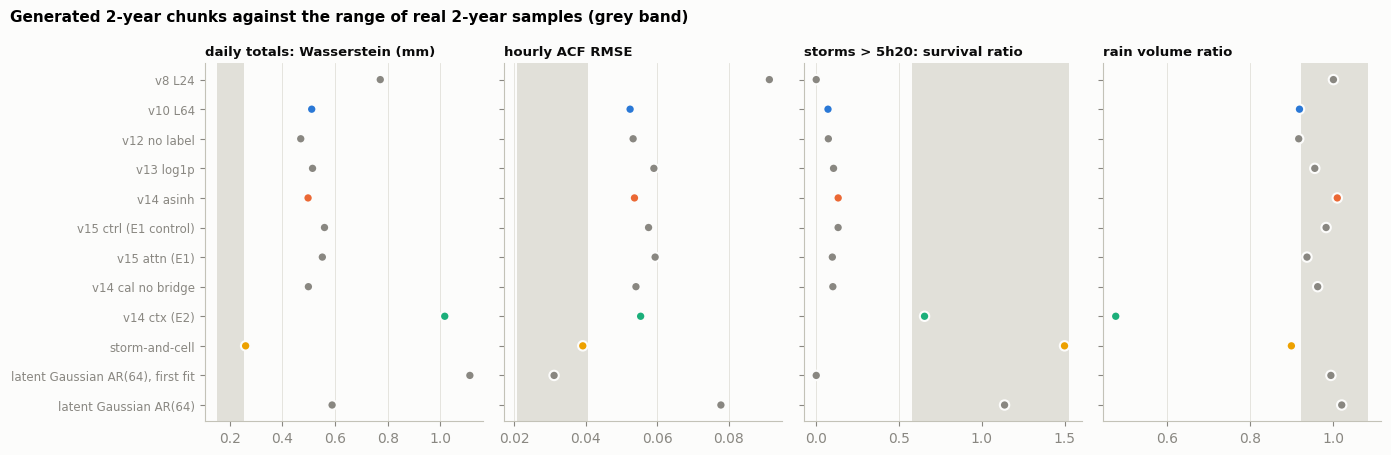

,w1_wet_5min,w1_wet_hours,w1_daily,hourly_acf_rmse,zero_gap_pp,volume_ratio,surv_ratio_320min,long_storms_yr,storms_ge10mm_ratio,rain_in_320min_ratio
real samples: min,0.003,0.034,0.153,0.021,0.382,0.922,0.578,9.5,0.857,0.900
real samples: max,0.009,0.048,0.254,0.041,0.823,1.084,1.525,19.0,1.247,1.071
v8 L24,0.009,0.061,0.772,0.091,0.790,1.000,0.000,0.0,0.381,0.144
v10 L64,0.004,0.043,0.512,0.052,0.939,0.918,0.071,1.0,0.476,0.357
v12 no label,0.005,0.041,0.470,0.053,1.023,0.917,0.073,1.0,0.476,0.341
v13 log1p,0.004,0.037,0.515,0.059,0.449,0.955,0.105,1.5,0.381,0.335
v14 asinh,0.004,0.021,0.498,0.054,0.186,1.009,0.132,2.0,0.571,0.358
v15 ctrl (E1 control),0.003,0.030,0.560,0.058,0.154,0.982,0.132,2.0,0.508,0.354
v15 attn (E1),0.003,0.046,0.552,0.059,0.543,0.936,0.097,1.5,0.508,0.363
v14 cal no bridge,0.004,0.027,0.499,0.054,0.361,0.962,0.100,1.5,0.476,0.389


In [13]:
F = pd.DataFrame({k: v.median() for k, v in E['floor_gen'].items()}).T
fl = E['floor']
frows = ['v8', 'v10', 'v12', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal', 'v14_ctx', 'bartlett_lewis',
         'arima_copula_len64', 'arima_copula_occ_len64']
panels = [('w1_daily', 'daily totals: Wasserstein (mm)'), ('hourly_acf_rmse', 'hourly ACF RMSE'),
          ('surv_ratio_320min', 'storms > 5h20: survival ratio'), ('volume_ratio', 'rain volume ratio')]
fig, axes = plt.subplots(1, 4, figsize=(14, 4.6), sharey=True)
yy = np.arange(len(frows))[::-1]
for ax, (m, title) in zip(axes, panels):
    ax.axvspan(fl[m].min(), fl[m].max(), color=GRID, lw=0)
    ax.scatter(F.loc[frows, m], yy, c=[col(n) if n in C else MUTED for n in frows], s=46, zorder=3,
               edgecolors=SURFACE, linewidths=1.5)
    ax.set_title(title, fontsize=9.5)
    ax.grid(axis='y', visible=False)
axes[0].set_yticks(yy); axes[0].set_yticklabels([lab(n) for n in frows], fontsize=8.5)
fig.suptitle('Generated 2-year chunks against the range of real 2-year samples (grey band)', x=0.01, ha='left',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

tfl = pd.concat([fl.agg(['min', 'max']).rename(index={'min': 'real samples: min', 'max': 'real samples: max'}),
                 F.loc[frows].rename(index=lab)])
tfl.round(3)

**Findings.** On 5-minute and hourly intensity distributions, dry fraction and volume, v14 is
**inside the real noise floor**: a 2-year chunk of v14 is as close to 2000–2007 as a real 2-year
sample is. It is **2–3× outside on daily totals** and **1.3–2.5× on hourly persistence**, and
far outside on long storms (0.13 vs 0.58–1.53). E2 is the first version inside the real range
on long storms (0.65–0.80), but outside on volume. One caution: v14 is sometimes *closer* than
real samples (e.g. hourly Wasserstein 0.021 vs 0.034–0.048) because real years genuinely differ
from each other and a stationary generator does not, so "closer than real" is not better.
The storm-and-cell model is the mirror image: inside or near the real range on daily totals
(0.26), hourly persistence (0.039) and long storms (1.50), but 2.5–6× outside on 5-minute and
hourly intensities and 2.7 pp too dry.

### 4.2 Coverage and realism of windows

Two complementary views on 5-hour windows that contain any rain (log-transformed, 16 PCA
dimensions fitted on real windows):
* **Precision / recall / density / coverage** (Naeem et al., ICML 2020): precision = generated
  windows that look like *some* real window (fidelity); recall and coverage = real windows the
  model can produce (diversity); density > 1 = crowding into dense regions.
* **Classifier two-sample test**: a gradient-boosted classifier tries to tell real from
  generated (3-fold ROC AUC; 0.5 = cannot). Run on 5-hour windows and on 1-day windows.
The real held-out years give the floor for both.

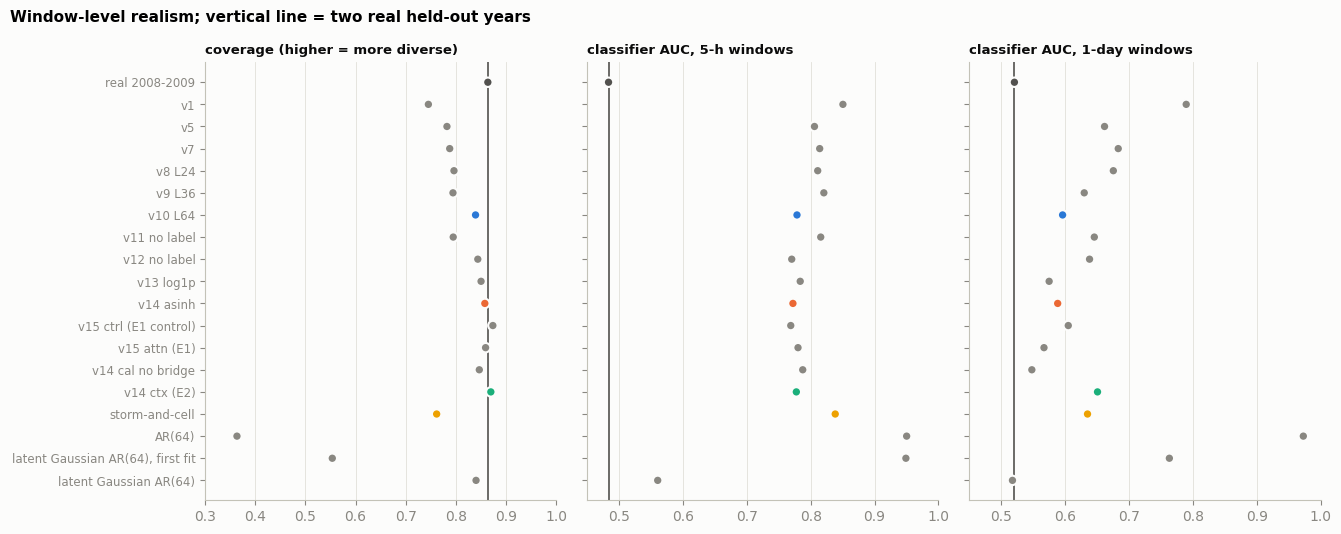

,precision,recall,density,coverage,C2ST AUC 5 h,C2ST AUC 1 day,windows with rain,wet steps per wet window
real 2008-2009,0.950,0.934,1.042,0.864,0.483,0.521,0.332,16.181
v1,0.937,0.921,0.949,0.745,0.850,0.790,0.677,9.422
v5,0.963,0.877,1.089,0.782,0.806,0.662,0.547,10.409
v7,0.966,0.852,1.094,0.788,0.814,0.683,0.546,10.590
v8 L24,0.974,0.867,1.115,0.796,0.811,0.676,0.541,9.957
v9 L36,0.953,0.890,1.036,0.794,0.821,0.630,0.532,10.471
v10 L64,0.966,0.908,1.088,0.839,0.779,0.596,0.405,13.032
v11 no label,0.969,0.878,1.067,0.794,0.816,0.646,0.575,9.876
v12 no label,0.970,0.915,1.110,0.844,0.770,0.638,0.397,13.197
v13 log1p,0.967,0.908,1.104,0.850,0.784,0.575,0.415,13.419


In [14]:
wrows = ['real 2008-2009', 'v1', 'v5', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal',
         'v14_ctx', 'bartlett_lewis', 'arima_len64', 'arima_copula_len64', 'arima_copula_occ_len64']
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.4), sharey=True)
yy = np.arange(len(wrows))[::-1]
for ax, (m, title, lo, hi) in zip(axes, [('coverage', 'coverage (higher = more diverse)', .3, 1),
                                         ('c2st_auc_5h', 'classifier AUC, 5-h windows', .45, 1),
                                         ('c2st_auc_1day', 'classifier AUC, 1-day windows', .45, 1)]):
    ax.axvline(W.loc['real 2008-2009', m], color=REAL, lw=1.2)
    ax.scatter(W.loc[wrows, m], yy, c=[col(n) if (n in C or n.startswith('real')) else MUTED for n in wrows], s=46,
               zorder=3, edgecolors=SURFACE, linewidths=1.5)
    ax.set_xlim(lo, hi); ax.set_title(title, fontsize=9.5); ax.grid(axis='y', visible=False)
axes[0].set_yticks(yy); axes[0].set_yticklabels([lab(n) for n in wrows], fontsize=8.5)
fig.suptitle('Window-level realism; vertical line = two real held-out years', x=0.01, ha='left', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

t42 = W.loc[wrows, ['precision', 'recall', 'density', 'coverage', 'c2st_auc_5h', 'c2st_auc_1day', 'wet_window_share',
                    'wet_steps_per_wet_window']].astype(float)
t42.columns = ['precision', 'recall', 'density', 'coverage', 'C2ST AUC 5 h', 'C2ST AUC 1 day', 'windows with rain',
               'wet steps per wet window']
t42.index = [lab(n) for n in wrows]
t42.round(3)

**Findings.**
* **Coverage metrics cannot separate diffusion from real data**: v10–v15 reach precision
  0.96–0.97, recall 0.90–0.93, coverage 0.83–0.86 (real held-out 0.95 / 0.93 / 0.86). Every real
  kind of 5-hour window is produced, and nothing alien is.
* **A classifier still tells them apart**: AUC 0.75–0.79 on 5-hour windows (real 0.48). The
  tell is occurrence: diffusion puts rain in 41–42% of 5-hour windows (real 33%) with 13–14 wet
  steps each (real 16). Rain is spread over too many windows, slightly too thinly. On 1-day
  windows AUC drops to 0.55–0.61.
* The first classical baselines are easy to detect (AUC 0.94–0.96; coverage 0.35–0.64): the first
  latent Gaussian fits rain in 88% of windows with 7 wet steps each. **The occurrence-matched latent Gaussian AR is the hardest
  generated series to detect** (AUC 0.56 at 5 hours, 0.52 at 1 day; coverage 0.84): it puts rain
  in 34% of windows (real 33%) with 17 wet steps each (real 16). The storm-and-cell model is closer (AUC 0.83 at 5 hours,
  0.61 at 1 day, level with v14) but covers less of the real variety (coverage 0.75): its rain
  sits in too few windows (26% vs 33%).
* The progression from early versions (C2ST 0.81–0.88) to v14 (0.78) is real but modest; this
  metric, not Gate A, shows how much realism is left to gain.

### 4.3 Memorisation

For each generated 5-hour window, the distance to its nearest training window, compared with
how close *genuinely new* real windows (2008–2009) get. Ratio < 1 = generated windows hug the
training data more than new real data do; "too close" = share of generated windows nearer than
the closest 5% of new real windows (5% expected if there is no copying).

In [15]:
mrows = [n for n in wrows if n in W.index]
t43 = W.loc[mrows, ['nn_dist_ratio', 'too_close_pct']].astype(float)
t43.columns = ['NN distance, generated / new real', 'too close (%)']
t43.index = [lab(n) for n in mrows]
t43.round(3).T

,real 2008-2009,v1,v5,v7,v8 L24,v9 L36,v10 L64,v11 no label,v12 no label,v13 log1p,v14 asinh,v15 ctrl (E1 control),v15 attn (E1),v14 cal no bridge,v14 ctx (E2),storm-and-cell,AR(64),"latent Gaussian AR(64), first fit",latent Gaussian AR(64)
"NN distance, generated / new real",1.003,1.171,0.761,0.872,0.776,0.712,0.984,0.661,0.915,0.975,0.931,0.954,0.858,1.015,0.912,1.498,2.724,1.331,0.833
too close (%),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


**Findings.** No version copies its training data: no generated window is closer than the
closest 5% of new real windows (too close = 0%), and v13–v15 sit at ratio 0.91–1.06, i.e. as
far from the training set as new real rain. The short-context models (v9 0.62, v11 0.66) hug the
training data more, together with lower coverage: less diverse, not memorising. The classical
models sit far from the training windows (ratio 1.3–2.8), as expected from models that never see
individual windows.

### 4.4 Utility: train on synthetic, test on real

A forecaster (gradient boosting on the last 6 hourly totals and the last 24-h total) is trained
on each series and tested on the real held-out years for two questions a flood controller
cares about: *will it rain (≥ 0.1 mm) next hour?* and *will the next 6 hours bring ≥ 2 mm?*
(persistence beyond a block). Reference: the same forecaster trained on real 2000–2007 (TRTR).

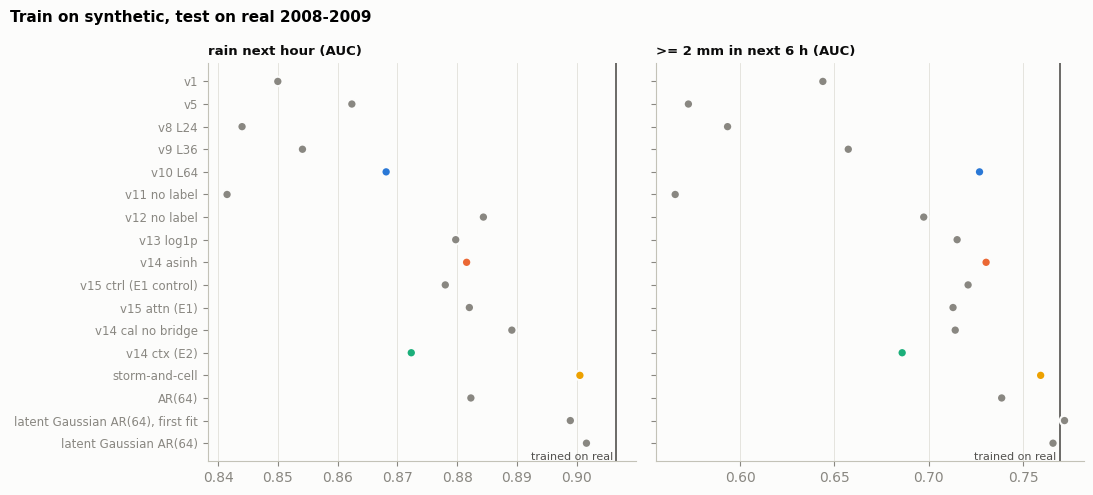

,auc_next_1h,auc_next_6h_2mm,share of real-trained (1 h),share of real-trained (6 h)
trained on real 2000-2007,0.907,0.769,1.000,1.000
v1,0.850,0.644,0.938,0.837
v5,0.862,0.573,0.951,0.744
v8 L24,0.844,0.593,0.931,0.771
v9 L36,0.854,0.657,0.942,0.854
v10 L64,0.868,0.727,0.958,0.945
v11 no label,0.841,0.566,0.928,0.735
v12 no label,0.884,0.697,0.975,0.906
v13 log1p,0.880,0.715,0.970,0.929
v14 asinh,0.882,0.730,0.972,0.949


In [16]:
trtr = T.loc['real 2000-2007']
urows = ['v1', 'v5', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15_ctrl', 'v15', 'v14_nobridge_cal', 'v14_ctx',
         'bartlett_lewis', 'arima_len64', 'arima_copula_len64', 'arima_copula_occ_len64']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
yy = np.arange(len(urows))[::-1]
for ax, (m, title) in zip(axes, [('auc_next_1h', 'rain next hour (AUC)'), ('auc_next_6h_2mm', '>= 2 mm in next 6 h (AUC)')]):
    ax.axvline(trtr[m], color=REAL, lw=1.2)
    ax.text(trtr[m], yy[-1] - 0.6, 'trained on real ', fontsize=8, color=REAL, ha='right', va='center')
    ax.scatter(T.loc[urows, m], yy, c=[col(n) if n in C else MUTED for n in urows], s=46, zorder=3,
               edgecolors=SURFACE, linewidths=1.5)
    ax.set_title(title, fontsize=9.5); ax.grid(axis='y', visible=False)
axes[0].set_yticks(yy); axes[0].set_yticklabels([lab(n) for n in urows], fontsize=8.5)
fig.suptitle('Train on synthetic, test on real 2008-2009', x=0.01, ha='left', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

t44 = T.loc[['real 2000-2007'] + urows].astype(float)
t44['share of real-trained (1 h)'] = t44['auc_next_1h'] / trtr['auc_next_1h']
t44['share of real-trained (6 h)'] = t44['auc_next_6h_2mm'] / trtr['auc_next_6h_2mm']
t44.index = ['trained on real 2000-2007'] + [lab(n) for n in urows]
t44.round(3)

**Findings.** Synthetic data from v14 trains a forecaster to **97% (next hour) and 95% (next 6
hours)** of what real data achieves; early versions reach 74–94%. **Classical baselines reach
99–100%** (storm-and-cell 99%), because these hourly-lag forecasts depend on hourly persistence,
which the classical models capture well (§3.5), and not on 5-minute structure, which they get
wrong.
Utility therefore depends on the downstream task. For flood control the decisive test remains
the agent-in-the-loop one (Gate B/C), which this proxy does not replace.

### 4.5 Conditioning: does the state label steer the rain?

For the versions generated from the seed-42 Markov plan, every output step is assigned the
state it was generated under and compared with real rain in that state (HMM states 0–3: drier
to stormier regimes).

In [17]:
st = {k: v for k, v in E['states'].items()}
real_st = st['real 2000-2007']
t45 = pd.DataFrame({lab(k): v['rain_mm_yr'] for k, v in st.items()}).T
t45.columns = [f'state {s} (mm/yr)' for s in range(4)]
ratio = t45 / t45.iloc[0].values
t45 = t45.round(0)
t45['mean |log2 ratio| vs real'] = np.log2(ratio).abs().mean(1).round(3)
t45

,state 0 (mm/yr),state 1 (mm/yr),state 2 (mm/yr),state 3 (mm/yr),mean |log2 ratio| vs real
real 2000-2007,501.0,694.0,803.0,1148.0,0.000
v10 L64,454.0,618.0,818.0,758.0,0.234
v10 init24,471.0,636.0,825.0,887.0,0.157
v13 log1p,471.0,619.0,837.0,895.0,0.168
v14 asinh,485.0,661.0,852.0,1052.0,0.082
v15 attn (E1),462.0,649.0,679.0,1205.0,0.131
v15 ctrl (E1 control),476.0,653.0,844.0,974.0,0.117
v14 ctx (E2),222.0,345.0,412.0,546.0,1.054


**Findings.** v10 under-produced the stormiest state by 34% (758 vs 1148 mm/yr); v13 by 22%;
**v14 by 8% (1052)**. The asinh transform makes the label do its job in the heavy regime.
Attention (v15) distorts it: state 2 −15%, state 3 +5%. E2 halves every state alike, so its dry
bias is not a labelling problem.

### 4.6 Inside the diffusion model

**Denoising error by true rain band** (`scripts/diagnose_denoising_error.py`, training years:
40 extreme steps; held-out years: only 7). v14 halves the error on dry steps and cuts it by about 30% on
light rain; its heavy-rain error *in mm* is larger because asinh gives heavy rain less of the model's range (at
1 mm, one model unit is 8.7× more rain than under StandardScaler). The volume bias on the
training years stays small (−4.7% heavy, −3.6% extreme).

In [18]:
den = []
for split in ['train', 'test']:
    d = pd.read_csv(os.path.join('..', 'results', 'transform_diagnostics', f'denoise_{split}', 'denoise_error_summary.csv'))
    d['split'] = 'training years' if split == 'train' else 'held-out years'
    den.append(d)
den = pd.concat(den).pivot_table(index=['split', 'band'], columns='run', values=['rmse_mm', 'vol_err'])
den.reindex(pd.MultiIndex.from_product([['training years', 'held-out years'],
                                        ['dry', 'light', 'moderate', 'heavy', 'extreme']])).round(4)

rmse_mm               vol_err                  
run                         v10    v13    v14     v10        v13    v14
training years dry        0.002  0.002  0.001     NaN        NaN    NaN
               light      0.016  0.014  0.011  -0.131 -1.013e-01 -0.044
               moderate   0.035  0.031  0.041  -0.044 -3.180e-02 -0.036
               heavy      0.061  0.068  0.175  -0.009 -8.600e-03 -0.047
               extreme    0.067  0.127  0.558  -0.001 -4.000e-04 -0.035
held-out years dry        0.002  0.002  0.001     NaN        NaN    NaN
               light      0.016  0.015  0.012  -0.133 -1.075e-01 -0.048
               moderate   0.034  0.031  0.043  -0.035 -3.140e-02 -0.042
               heavy      0.059  0.074  0.211  -0.011 -1.910e-02 -0.109
               extreme    0.083  0.167  0.694   0.005  8.600e-03 -0.153

**Training and sampling.** E1 and its control both continue from v14 for 200 epochs. Their
training losses are indistinguishable, yet their samples differ (§5.1): attention changed *what*
the model generates without changing *how well* it fits.

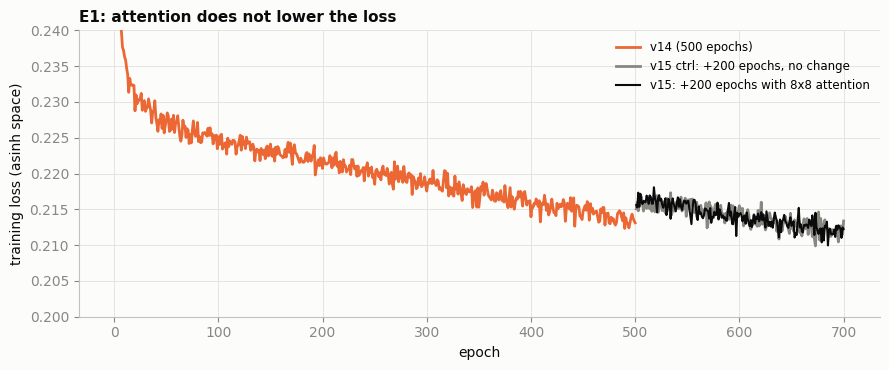

,best loss,network calls per block,blocks per 10 years,blocks generated,network calls per 10 years (M)
v14 (production),0.212,71,17800.0,in parallel,1.26
v15,0.210,71,17800.0,in parallel,1.26
v15 ctrl,0.210,71,17800.0,in parallel,1.26
"E2 (K=2, 10x resampling)",NaN,323,21900.0,one after another,7.07
E2 without resampling (proposed),NaN,71,21900.0,one after another,1.55


In [19]:
hist = {r: pd.read_csv(os.path.join('..', 'logs', 'ImagenFew', 'Rainfall_Regime', r, 'history.csv')) for r in ['v14', 'v15', 'v15_ctrl']}
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(hist['v14'].epoch, hist['v14'].loss, color=col('v14'), label='v14 (500 epochs)')
ax.plot(hist['v15_ctrl'].epoch + 500, hist['v15_ctrl'].loss, color=MUTED, label='v15 ctrl: +200 epochs, no change')
ax.plot(hist['v15'].epoch + 500, hist['v15'].loss, color=INK, lw=1.5, label='v15: +200 epochs with 8x8 attention')
ax.set_ylim(0.20, 0.24); ax.set_xlabel('epoch'); ax.set_ylabel('training loss (asinh space)')
ax.legend(fontsize=8.5); ax.set_title('E1: attention does not lower the loss')
plt.tight_layout(); plt.show()

cost = pd.DataFrame({
    'best loss': [hist[r].loss.min() for r in ['v14', 'v15', 'v15_ctrl']] + [np.nan, np.nan],
    'network calls per block': [71, 71, 71, 323, 71],
    'blocks per 10 years': [17.8e3, 17.8e3, 17.8e3, 21.9e3, 21.9e3],
    'blocks generated': ['in parallel', 'in parallel', 'in parallel', 'one after another', 'one after another'],
}, index=['v14 (production)', 'v15', 'v15 ctrl', 'E2 (K=2, 10x resampling)', 'E2 without resampling (proposed)'])
cost['network calls per 10 years (M)'] = (cost['network calls per block'] * cost['blocks per 10 years'] / 1e6).round(2)
cost

## 5. Ablations, year by year

### 5.1 Model changes (same seed-42 plan, 10 paired years)

Each row compares two versions on the same planned years: mean difference (second minus
first) with 95% interval, and how many of the 10 years moved in that direction. Each version is
still one trained model, so this measures generation-level consistency, not training-seed
robustness.

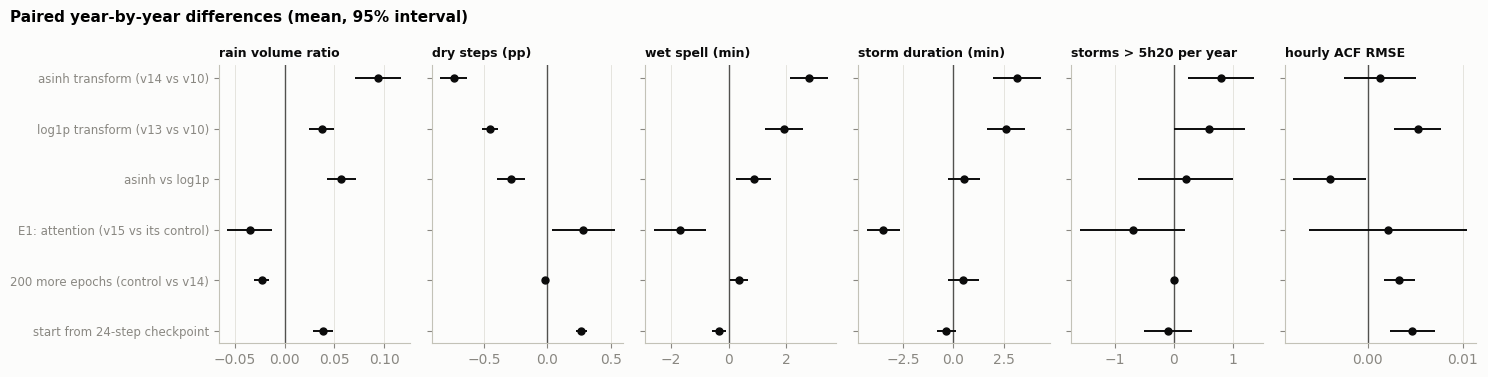

metric,volume_ratio,zero_pct,wet_spell_min,storm_dur_min,long_storms,hourly_acf_rmse
comparison,,,,,,
asinh transform (v14 vs v10),"+0.094 [+0.071, +0.117]","-0.741 [-0.845, -0.637]","+2.785 [+2.130, +3.440]","+3.176 [+1.990, +4.363]","+0.800 [+0.236, +1.364]","+0.001 [-0.002, +0.005]"
log1p transform (v13 vs v10),"+0.037 [+0.025, +0.049]","-0.453 [-0.513, -0.393]","+1.911 [+1.248, +2.573]","+2.630 [+1.701, +3.558]","+0.600 [-0.003, +1.203]","+0.005 [+0.003, +0.008]"
asinh vs log1p,"+0.057 [+0.043, +0.072]","-0.288 [-0.401, -0.175]","+0.874 [+0.264, +1.484]","+0.547 [-0.251, +1.344]","+0.200 [-0.612, +1.012]","-0.004 [-0.008, -0.000]"
E1: attention (v15 vs its control),"-0.035 [-0.057, -0.013]","+0.285 [+0.039, +0.531]","-1.699 [-2.600, -0.798]","-3.484 [-4.297, -2.671]","-0.700 [-1.595, +0.195]","+0.002 [-0.006, +0.010]"
200 more epochs (control vs v14),"-0.023 [-0.030, -0.016]","-0.015 [-0.044, +0.013]","+0.348 [+0.041, +0.656]","+0.506 [-0.244, +1.255]","+0.000 [+0.000, +0.000]","+0.003 [+0.002, +0.005]"
start from 24-step checkpoint,"+0.039 [+0.029, +0.049]","+0.269 [+0.223, +0.315]","-0.320 [-0.564, -0.076]","-0.344 [-0.830, +0.141]","-0.100 [-0.506, +0.306]","+0.005 [+0.002, +0.007]"


In [20]:
PY = E['per_year']
comparisons = [('v10', 'v14', 'asinh transform (v14 vs v10)'), ('v10', 'v13', 'log1p transform (v13 vs v10)'),
               ('v13', 'v14', 'asinh vs log1p'), ('v15_ctrl', 'v15', 'E1: attention (v15 vs its control)'),
               ('v14', 'v15_ctrl', '200 more epochs (control vs v14)'), ('v10', 'e1_v10ckpt24', 'start from 24-step checkpoint')]
metrics = [('volume_ratio', 'rain volume ratio'), ('zero_pct', 'dry steps (pp)'), ('wet_spell_min', 'wet spell (min)'),
           ('storm_dur_min', 'storm duration (min)'), ('long_storms', 'storms > 5h20 per year'),
           ('hourly_acf_rmse', 'hourly ACF RMSE')]
res = pd.DataFrame([dict(comparison=t, **ev.paired(PY[a], PY[b], m)) for a, b, t in comparisons for m, _ in metrics])
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.8), sharey=True)
yy = np.arange(len(comparisons))[::-1]
for ax, (m, title) in zip(axes, metrics):
    r = res[res.metric == m].set_index('comparison').loc[[t for _, _, t in comparisons]]
    ax.axvline(0, color=REAL, lw=1)
    ax.errorbar(r.mean_diff, yy, xerr=[r.mean_diff - r.ci_low, r.ci_high - r.mean_diff], fmt='o', color=INK,
                ms=5, elinewidth=1.4, capsize=0)
    ax.set_title(title, fontsize=9); ax.grid(axis='y', visible=False)
axes[0].set_yticks(yy); axes[0].set_yticklabels([t for _, _, t in comparisons], fontsize=8.5)
fig.suptitle('Paired year-by-year differences (mean, 95% interval)', x=0.01, ha='left', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

t51 = res.assign(**{'effect [95% CI]': res.apply(lambda r: f"{r.mean_diff:+.3f} [{r.ci_low:+.3f}, {r.ci_high:+.3f}]", axis=1),
                    'years up': res.years_up.astype(str) + '/' + res.years.astype(str)})
t51.pivot(index='comparison', columns='metric', values='effect [95% CI]').loc[[t for _, _, t in comparisons], [m for m, _ in metrics]]

In [21]:
t51.pivot(index='comparison', columns='metric', values='years up').loc[[t for _, _, t in comparisons], [m for m, _ in metrics]]

metric,volume_ratio,zero_pct,wet_spell_min,storm_dur_min,long_storms,hourly_acf_rmse
comparison,,,,,,
asinh transform (v14 vs v10),10/10,0/10,10/10,9/10,6/10,5/10
log1p transform (v13 vs v10),10/10,0/10,10/10,9/10,4/10,10/10
asinh vs log1p,10/10,0/10,9/10,6/10,3/10,3/10
E1: attention (v15 vs its control),2/10,8/10,1/10,0/10,2/10,6/10
200 more epochs (control vs v14),0/10,2/10,7/10,7/10,0/10,10/10
start from 24-step checkpoint,10/10,10/10,2/10,2/10,1/10,9/10


**Findings.**
* **Transform**: asinh adds rain volume (+0.094, 10/10 years), removes dry steps (−0.74 pp, 10/10
  years), lengthens wet spells (+2.8 min, 10/10) and storms (+3.2 min, 9/10). log1p goes the same
  way at about half the size and slightly worsens hourly persistence (10/10). asinh beats log1p
  on volume (10/10) and wet spells (9/10).
* **E1 (attention at 8×8) is a negative result**: storms **−3.5 min [−4.3, −2.7], shorter in
  10/10 years**; wet spells −1.7 min; less rain. The prediction (sub-block structure improves,
  cliff unchanged) was wrong in its first half. Attention over 64 single time steps let the model
  sharpen short structure at the expense of persistence, with no loss gain.
* **200 more epochs alone** changed little (rain −2%, hourly ACF slightly worse, 10/10): v14 was
  effectively converged in what it generates despite the still-falling loss.
* **Initialisation matters too** (Sept 22 audit confound): starting v10 from the 24-step
  checkpoint gives heavier extremes (max 1-h rain +3.2 mm, 10/10) at the same block length.

### 5.2 Assembly: bridges and crossfade

The paired assembly ablation (Sept 30, `scripts/ablate_block_assembly.py`) joins the *same* v14
blocks four ways; the no-bridge calendar run (§3.6) is the full-length check.

In [22]:
asm = pd.read_csv(os.path.join('..', 'results', 'assembly_ablation', 'assembly_v14_2y_seed42.csv'), index_col=0)
asm.round(3)

,real (2000-2007),A bridge + xfade,B no bridge + xfade,C bridge + hard join,D no bridge + hard join
volume mm/yr,709.577,692.596,686.045,694.647,685.147
zero %,90.796,91.374,91.408,91.596,91.623
wet spell min,31.975,28.487,28.482,27.754,27.832
storms/yr,697.125,730.500,729.500,715.500,711.500
storm dur min,61.823,54.603,54.465,54.036,54.178
P(storm > 240 min) %,3.837,2.533,2.536,2.376,2.460
storms > 320 min /yr,14.250,1.000,1.000,1.000,1.000
rain in storms > 320 min %,21.437,2.370,2.393,1.705,1.729
P99 wet,0.588,0.629,0.627,0.646,0.640
P99.9 wet,1.598,1.546,1.543,1.583,1.559


**Findings.** Bridge blocks change nothing measurable in the paired test (all metrics to the
third digit), while the crossfade shifts a few by 1–3%. Neither touches the cliff. But bridges
were what shifted the calendar: dropping them is free and fixes the seasonal cycle (0.62 → 0.97).

### 5.3 Context chaining (E2) and why it ran dry

E2 generates each block with the previous block's last 80 minutes as known context (RePaint
in-filling, 10 resampling passes). Two partial runs exist (4 chains × 2 years, Markov and exact
calendar). A CPU pilot then separated the two ingredients, on the v14 checkpoint over the same 11
days: context with and without resampling, and no context at all
(`results/e2_pilot/e2_mechanism_pilot_11days.npz`).

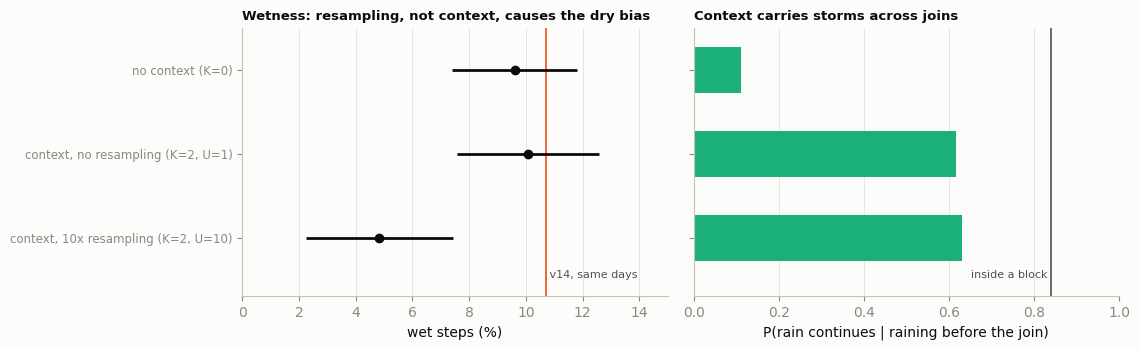

,chains,wet_pct,wet_pct_se,continues_across_join,continues_inside_block
no context (K=0),8.0,9.606,1.129,0.111,0.848
"context, no resampling (K=2, U=1)",8.0,10.074,1.272,0.617,0.832
"context, 10x resampling (K=2, U=10)",4.0,4.837,1.321,0.632,0.843
"v14 itself, same days",NaN,10.720,NaN,NaN,NaN


In [23]:
pil = np.load(os.path.join('..', 'results', 'e2_pilot', 'e2_mechanism_pilot_11days.npz'))
n = pil['v14_same_days'].shape[0]
def pilot_stats(ch, first, step):
    w = 100 * (ch > 0).mean(1)
    seams = np.arange(first, n, step)
    inside = np.setdiff1d(np.arange(1, n), seams)
    cont = np.mean([x[s] > 0 for x in ch for s in seams if x[s - 1] > 0])
    within = np.mean([x[s] > 0 for x in ch for s in inside if x[s - 1] > 0])
    return dict(chains=len(ch), wet_pct=w.mean(), wet_pct_se=w.std(ddof=1) / np.sqrt(len(w)),
                continues_across_join=cont, continues_inside_block=within)
pt = pd.DataFrame({'no context (K=0)': pilot_stats(pil['K0_U1'], 64, 64),
                   'context, no resampling (K=2, U=1)': pilot_stats(pil['K2_U1'], 64, 48),
                   'context, 10x resampling (K=2, U=10)': pilot_stats(pil['K2_U10_cluster'], 64, 48)}).T
pt.loc['v14 itself, same days', 'wet_pct'] = 100 * (pil['v14_same_days'] > 0).mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.6))
setups = ['no context (K=0)', 'context, no resampling (K=2, U=1)', 'context, 10x resampling (K=2, U=10)']
yy = np.arange(3)[::-1]
a1.axvline(pt.loc['v14 itself, same days', 'wet_pct'], color=col('v14'), lw=1.4)
a1.text(pt.loc['v14 itself, same days', 'wet_pct'], -0.45, ' v14, same days', fontsize=8, color=REAL, va='center')
a1.errorbar(pt.loc[setups, 'wet_pct'], yy, xerr=1.96 * pt.loc[setups, 'wet_pct_se'], fmt='o', color=INK, ms=6, capsize=0)
a1.set_yticks(yy); a1.set_yticklabels(setups, fontsize=8.5); a1.set_xlim(0, 15); a1.set_ylim(-0.7, 2.5)
a1.set_xlabel('wet steps (%)')
a1.set_title('Wetness: resampling, not context, causes the dry bias', fontsize=9.5); a1.grid(axis='y', visible=False)
a2.barh(yy, pt.loc[setups, 'continues_across_join'], color=col('v14_ctx'), height=0.55)
a2.axvline(pt.loc[setups, 'continues_inside_block'].mean(), color=REAL, lw=1.2)
a2.text(pt.loc[setups, 'continues_inside_block'].mean(), -0.45, 'inside a block ', fontsize=8, color=REAL, ha='right', va='center')
a2.set_yticks(yy); a2.set_yticklabels([]); a2.set_xlim(0, 1); a2.set_ylim(-0.7, 2.5)
a2.set_xlabel('P(rain continues | raining before the join)')
a2.set_title('Context carries storms across joins', fontsize=9.5); a2.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
pt.round(3)

In [24]:
e2 = pd.DataFrame({'E2 Markov: chain-years': PY['v14_ctx'].volume_ratio.values})
print('rain volume ratio of every E2 chain-year (real = 1; v14 years 1-2:',
      PY['v14'].volume_ratio.values[:2].round(2), ')')
e2.round(3).T

rain volume ratio of every E2 chain-year (real = 1; v14 years 1-2: [1.01 0.85] )


,0,1,2,3,4,5,6,7
E2 Markov: chain-years,0.646,0.464,0.42,0.467,0.528,0.446,0.481,0.453


**Findings.**
* **Context works as intended**: rain continues across a join with probability 0.62–0.63 when
  the previous 80 minutes are given, against **0.11 without context** (inside a block: 0.83–0.85).
  In the full runs this removed the cliff (survival at 5h20: 0.73–0.79, inside the real range).
* **The dry bias comes from RePaint resampling, not from context**: with the same context and no
  resampling, wetness is **10.1% ± 1.3** (v14 10.7%, no context 9.6%); with 10 resampling passes
  it is **4.8% ± 1.3**, and every chain-year of the full runs lies at 0.40–0.66 of real volume (the exact-calendar E2 run,
  no longer tabulated, gave the same range).
  Resampling repeatedly re-noises and re-denoises the free part of the image so it agrees with
  the known part; on data that are 91% exactly zero, each pass nudges the sample towards the dry
  mode, so resampling acts as a **mode-seeking** step.
* Caveats: the pilot is 8 chains × 11 days; whether a no-resampling chain stays stable over 10
  years (drift) is untested.

### 5.4 Diffusion against classical baselines

Classical generators fitted to the same 2000–2007 training years, against v14: the field's
standard storm-and-cell model (randomised Bartlett-Lewis, intensity scaling with cell speed as in
Kaczmarska et al. 2014, fitted per month by simulated method of moments,
`scripts/baselines/run_bartlett_lewis.py`) and five AR / latent Gaussian AR models with 5-hour memory, including the latent Gaussian AR refitted
on Oct 5 so its latent correlation reproduces real rain occurrence
(`scripts/baselines/run_copula_arima_occ.py`). In the literature these are Gaussian-copula models with
empirical marginals (the ARTA / CoSMoS family); here they are called latent Gaussian AR.

In [25]:
comp_metrics = [('volume_mm_yr', 'rain mm/yr', 'close'), ('zero_pct', 'dry steps %', 'close'),
                ('single_step_showers_pct', 'single-step showers %', 'close'), ('wet_spell_min', 'wet spell (min)', 'close'),
                ('storm_dur_min', 'storm duration (min)', 'close'), ('long_storms_yr', 'storms > 5h20 /yr', 'close'),
                ('idf_cells_in_band', 'IDF cells in band (of 15)', 'high'), ('hourly_acf_rmse', 'hourly ACF RMSE', 'low'),
                ('var_scaling_rmse', 'variance-scaling error', 'low'), ('monthly_r', 'monthly cycle r', 'high')]
crow = ['v14', 'v14_nobridge_cal'] + BASE
tb = H.loc[crow, [m for m, _, _ in comp_metrics]].astype(float)
tb = pd.concat([H.loc[['real 2000-2007'], [m for m, _, _ in comp_metrics]].astype(float), tb])
extra = pd.DataFrame({'coverage': W.loc[crow, 'coverage'], 'C2ST AUC 5 h': W.loc[crow, 'c2st_auc_5h'],
                      'TSTR share (1 h)': T.loc[crow, 'auc_next_1h'] / trtr['auc_next_1h']})
tb = tb.join(extra)
tb.columns = [t for _, t, _ in comp_metrics] + list(extra.columns)
tb.index = [lab(n) for n in tb.index]
tb.round(3)

,rain mm/yr,dry steps %,single-step showers %,wet spell (min),storm duration (min),storms > 5h20 /yr,IDF cells in band (of 15),hourly ACF RMSE,variance-scaling error,monthly cycle r,coverage,C2ST AUC 5 h,TSTR share (1 h)
real 2000-2007,709.577,90.796,38.062,31.975,61.823,14.25,15.0,0.000,0.000,1.000,NaN,NaN,NaN
v14 asinh,716.120,91.010,38.294,30.467,57.324,1.90,12.0,0.051,0.155,-0.107,0.858,0.772,0.972
v14 cal no bridge,697.651,91.092,38.143,30.798,57.511,1.40,12.0,0.054,0.171,0.965,0.846,0.788,0.981
storm-and-cell,634.928,93.361,7.412,67.179,80.366,13.80,10.0,0.034,0.100,0.883,0.762,0.838,0.993
AR(64),2291.077,48.784,24.328,29.218,44.311,7.70,0.0,0.024,0.481,0.114,0.364,0.950,0.973
"latent Gaussian AR(64), first fit",703.162,90.795,74.801,7.095,19.484,0.00,0.0,0.029,0.516,0.231,0.554,0.949,0.992
latent Gaussian AR(64),714.908,90.831,39.436,32.616,64.169,15.80,3.0,0.074,0.203,0.295,0.840,0.560,0.994
seas. latent Gaussian AR(64),716.051,90.675,74.654,7.118,19.598,0.00,0.0,0.026,0.454,0.233,0.615,0.951,0.989


**Findings.**
* **Against the first AR / latent Gaussian fits, diffusion wins almost everything** involving the shape of
  rain in time: storm duration (57 vs 20 min; real 62), wet spells (31 vs 7 min), single-step
  showers (38% vs 75%; real 38%), extremes (12/15 IDF cells vs 0/15), window coverage (0.86 vs 0.60)
  and realism (C2ST 0.78 vs 0.94). That gap came from the fit (latent lag-1 correlation 0.47 vs
  0.976 needed).
* **Against the occurrence-matched latent Gaussian AR the picture splits.** It wins storm timing (64 vs
  57 min; storms > 5h20 15.8 vs 1.9 per year; real 14.25) and realism (C2ST 0.56 vs 0.78), and ties
  on showers and spells. Diffusion wins extremes (IDF 12/15 vs 3/15; wettest day 47 vs 90 mm, real
  51) and 5-minute and hourly persistence. Its single latent process cannot be very
  persistent for occurrence (lag-1 ρ 0.976) and moderately persistent for amounts (0.85), so heavy
  rain lasts hours: 1-hour to 1-day design rain is 1.3–1.9× real and sewer overflow 1.47× real
  (v14 0.62×; v16, the two-level generator, 1.00×).
* **Against the storm-and-cell model, the two are complementary.** Diffusion wins the 5-minute
  scale: shower lengths, dry fraction, 5–30-minute extremes (0.9–1.0× the real average vs 0.55–0.8×),
  window realism and coverage. The storm-and-cell model wins everything longer than a few hours:
  long storms (13.8 vs 1.9 per year; real 14.25), daily totals, hourly persistence, variance across
  scales and the seasonal cycle. Neither reaches the real 24-hour extremes.

## 6. What can be reported

| # | Claim | Evidence | Strength |
| :-- | :--- | :--- | :--- |
| 1 | The data parametrisation of a diffusion model decides which intensity range it resolves. **asinh** recovers storm-edge drizzle and fixes the water balance: volume +9.4%, wet spells +2.8 min, storms +3.2 min, heavy-state rain −34% → −8% | §3.1, §4.5, §5.1: 10/10 and 9/10 paired years; Gate A 11 → 14/18 | Strong at generation level; one training run per transform |
| 2 | The trade-off is explicit: asinh spends model resolution on light rain, making heavy-rain values ~9× coarser at 1 mm, yet generated extremes stay in band (IDF 12/15 up to 6 h) | §4.6 denoising and transform slopes; §3.4 | Strong (mechanism measured) |
| 3 | Assembly heuristics are second-order for storms but first-order for seasons: bridges have no measurable effect on storm statistics, yet removing them takes the monthly cycle from r = 0.62 to 0.97 | §5.2 paired ablation; §3.6 | Strong (large effect, mechanism known; one realisation) |
| 4 | Against classical generators, diffusion's clear edge is extremes and short-scale persistence. A latent Gaussian AR fitted to rain occurrence matches storm timing and long storms and is harder to detect (C2ST 0.56 vs 0.78), but over-produces extremes (1.3–1.9× from 1 h) and sewer overflow (1.47×); against the storm-and-cell model the two are complementary: diffusion wins the 5-minute scale, storm-and-cell wins long storms, daily totals, persistence and seasonality | §5.4, §3.3, §3.5, §4.2 | Strong (one realisation each) |
| 5 | The dominant remaining failure is architectural: blocks generated independently cap storms at the block length (survival 0.07–0.13 at 5h20 vs real 0.58–1.53). Context length moves the wall; labels, transform and attention do not | §3.3, §4.1 | Strong (seen in every version) |
| 6 | Context chaining removes the wall (0.73–0.79), but RePaint resampling is mode-seeking on zero-inflated data and halves the rain; without resampling, wetness is preserved | §5.3 full runs + pilot | Mechanism: medium–strong. Full-length no-resampling run: pending |
| 7 | Negative: full-resolution attention (E1) shortens storms (−3.5 min, 10/10 years) with no loss improvement | §5.1, §4.6 | Strong at generation level |
| 8 | No memorisation: generated windows are as far from training data as new real data | §4.3 | Strong |
| 9 | Methodology: real held-out years pass only 10/18 Gate A checks; pass thresholds should be calibrated against a real-vs-real noise floor, and C2ST separates models where coverage metrics saturate | §2, §4.1, §4.2 | Strong |
| 10 | The training series is a 4-gauge average whose 5-minute peaks are ~40% below a single gauge's (and below the official KOSTRA values); the real gauges themselves agree with KOSTRA within ~5% from 15 minutes up | §3.7 | Strong (direct measurement) |

**Limitations.** One training run per configuration; one realisation per version (paired years
help but do not replace seeds); E2 runs are partial (2 years per chain); 8 training years limit
the extremes reference; the TSTR proxy is not the downstream RL test (Gate B/C).

## 7. One good idea: context chaining without resampling

**Idea.** Keep E2's context (the previous block's last 80 minutes are known while the next
block is generated) but **switch RePaint resampling off** (one pass per solver step).

**Why this one.** It targets the largest remaining gap (§3.3: long storms carry 21% of real rain,
2% of v14's) with the only mechanism that has moved it (E2: survival 0.13 → 0.73–0.79), and the
pilot (§5.3) says the side effect disappears without resampling: wetness 10.1% ± 1.3 instead of
4.8%, while rain still continues across joins (0.62 vs 0.11). No retraining, no new code, and 4.5×
fewer network calls than E2 (71 instead of 323 per block).

**Run** (cluster, ~10–12 h for 4 chains × 10 years):
`RESAMPLE=1 sbatch scripts/submit_generation_v14_ctx.sh markov` → `rainfall_synthetic_10y_v14_ctx_u1*.csv`

**Decided in advance** (`scripts/score_context_generation.py`, baseline v14):
* success: storms > 5h20 ≥ 10/yr and ≥ 15% of rain in them (v14: 1.9/yr, 2.2%)
* must not break: zero fraction within 1 pp of real, volume ratio 0.95–1.05, wet-run histogram
  within 2 pp per bin, lag-1 ACF within 0.02
* drift: no significant year-on-year trend in volume or hourly ACF relative to v14

**If it drifts or still runs dry**, the model itself must learn to continue a history: fine-tune
with random known-prefix masks (E3 in `code_plan/NEXT_STEPS_AFTER_v14.md`), which turns the
continuation from an approximation into something trained for.

**A second idea, from the baseline comparison.** The storm-and-cell model and diffusion fail in
opposite places (§5.4), which suggests a two-level generator: a storm-scale model decides *when and
for how long* it rains (long storms, seasons, daily totals) and the diffusion model fills in the
5-minute detail inside each storm. That needs the diffusion model to accept a coarse rain signal as
input, so it is a larger step than the one above.

## Appendix: definitions and reproduction

* Wet step: ≥ 0.005 mm per 5 minutes. Storm: ≥ 3 consecutive wet steps, no gap tolerance.
* Calendar: 365-day years from 1 January for both real and generated data (how calendar
  assembly indexes the seasons); monthly correlations therefore differ by up to ±0.05 from
  `gate_a_scorecard.py`, which uses the generated date column with leap days.
* IDF: annual maxima of rolling 15-min to 24-h totals, Gumbel method of moments, T = 2, 5, 10.
* Windows: non-overlapping 64-step (5h20) windows with any rain; features log(1 + x / 0.1 mm);
  16 PCA components fitted on real windows; k = 5 for precision/recall/density/coverage. 1-day
  windows: 288 steps summed to 15 minutes. C2ST: gradient boosting, 3-fold ROC AUC.
* Noise floor: four leave-two-years-out chunks of 2000–2007 plus 2008–2009 against 2000–2007.
* All numbers: `python scripts/eval_suite.py --refresh` (≈ 4 minutes), then run this notebook.